# EEG-Based Schizophrenia Detection: Replication & Critical Evaluation

**Thesis:** *Wavelet-Based EEG Classification for Schizophrenia Detection*

**Author:** Bamdad Booyeh  
**GitHub:** https://github.com/BamdadBooyeh  
**Dataset:** Warsaw EEG Dataset — https://repod.icm.edu.pl/dataset.xhtml?persistentId=doi:10.18150/repod.0107441

---

## What this notebook does

This notebook fully reproduces the experiments in the thesis:

1. **Feature extraction** — CWT (2,603-dim), DWT (1,368-dim), WST (456-dim), Raw stats (228-dim)
2. **Data leakage demonstration** — leaky epoch-level CV vs honest subject-independent CV
3. **Classical ML** — 6 classifiers × 3 wavelet feature sets × 10-fold GroupKFold
4. **Leakage gap matrix** — paper-exact hyperparameters, full heatmap
5. **Neural networks** — EEGNet, ShallowConvNet, EEG-TCNet, Feature MLP

## How to run

**First time (full pipeline):**
```
Run cells in order: 1 → 2 → 3 → 4 → 5 → 6 → 7 → 8 → 9 → 10 → 11 → 12a–12e → 13 → 14
```
Feature extraction (Cell 5) takes ~30 minutes. All outputs are cached automatically.

**Subsequent sessions (skip re-extraction):**
```
Run cells: 1 → 2 → 3 → 4 (skip 5) → 6 → 7 → 8 → ...
```

## Runtime estimates (T4 GPU)

| Step | Time |
|---|---|
| Feature extraction (Cell 5) | ~30 min (once only) |
| Classical ML, all features (Cells 8–10) | ~45 min |
| Leakage analysis (Cell 11) | ~20 min |
| MLP experiments (Cells 12a–12b) | ~10 min each |
| ShallowConvNet (Cell 12c) | ~15 min |
| EEGNet (Cell 12d) | ~25 min |
| EEG-TCNet (Cell 12e) | ~30 min |

## Cell 1 — Install dependencies

In [2]:
# Install all required packages
# Run this once per Colab session
!pip install mne kymatio pywavelets scipy scikit-learn xgboost torch joblib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 3.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


## Cell 2 — Imports

In [3]:
import os, time, warnings, pickle
import numpy as np
import mne
import pywt
import joblib
from scipy import stats
from kymatio.numpy import Scattering1D
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, confusion_matrix, cohen_kappa_score,
    classification_report, f1_score, roc_auc_score, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
print(f'PyTorch: {torch.__version__}')
print(f'MNE    : {mne.__version__}')

Device : cpu
PyTorch: 2.11.0+cpu
MNE    : 1.12.1


## Cell 3 — Configuration

**Edit `DATA_DIR` to point to your downloaded Warsaw EEG dataset.**

Dataset download: https://repod.icm.edu.pl/dataset.xhtml?persistentId=doi:10.18150/repod.0107441

In [4]:
# ── Mount Google Drive (Colab only) ───────────────────
# Skip this block if running locally
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print('Not running in Colab — skipping Drive mount')

# ── EDIT THESE TWO PATHS ──────────────────────────────
# DATA_DIR : folder containing the 28 .edf files
# CACHE_DIR: where extracted features and results are saved
DATA_DIR  = '/content/drive/MyDrive/Schizodata'   # <-- edit this
CACHE_DIR = '/content/drive/MyDrive/thesis_cache'  # <-- edit this
# ──────────────────────────────────────────────────────

os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(os.path.join(CACHE_DIR, 'figures'), exist_ok=True)

# ── Signal parameters (match Gosala et al. 2023) ──────
EEG_CHANNELS = [
    'Fp1','Fp2','F7','F3','Fz','F4','F8',
    'T3','C3','Cz','C4','T4','T5','P3','Pz','P4','T6','O1','O2'
]
N_CH        = len(EEG_CHANNELS)   # 19
FS          = 250                 # sampling rate (Hz)
EPOCH_SEC   = 5                   # epoch duration (seconds)
OVERLAP_SEC = 1                   # overlap between epochs (seconds)
EPOCH_LEN   = FS * EPOCH_SEC      # 1250 samples per epoch

# ── CWT parameters ────────────────────────────────────
# Mexican Hat wavelet, scales 1-125 → covers 0.5-45 Hz
# Scale-frequency: f = (f_c * FS) / scale, f_c(mexh) ≈ 0.25
CWT_WAVELET = 'mexh'
CWT_SCALES  = np.arange(1, 126)  # 125 scales

# ── DWT parameters ────────────────────────────────────
# Daubechies-4, 4 levels → 5 subbands: A4,D4,D3,D2,D1
DWT_WAVELET = 'db4'
DWT_LEVEL   = 4

# ── WST parameters ────────────────────────────────────
# J=6 is the safe maximum for EPOCH_LEN=1250 (shape >= 2^J)
# Q=8 wavelets per octave (frequency resolution)
WST_J = 6
WST_Q = 8

print(f'DATA_DIR      : {DATA_DIR}')
print(f'CACHE_DIR     : {CACHE_DIR}')
print(f'Channels      : {N_CH}')
print(f'Epoch length  : {EPOCH_LEN} samples ({EPOCH_SEC}s @ {FS}Hz)')
print(f'CWT scales    : {CWT_SCALES[0]}–{CWT_SCALES[-1]}')
print(f'DWT           : {DWT_WAVELET}, {DWT_LEVEL} levels → 5 subbands')
print(f'WST           : J={WST_J}, Q={WST_Q}')

Mounted at /content/drive
DATA_DIR      : /content/drive/MyDrive/Schizodata
CACHE_DIR     : /content/drive/MyDrive/thesis_cache
Channels      : 19
Epoch length  : 1250 samples (5s @ 250Hz)
CWT scales    : 1–125
DWT           : db4, 4 levels → 5 subbands
WST           : J=6, Q=8


## Cell 4 — Feature extraction functions

Defines the three wavelet feature extractors and the shared 12-statistic function.
No computation happens here — functions are called in Cell 5.

In [9]:
# ── Build WST operator once (expensive, reused for all epochs) ────
scattering    = Scattering1D(J=WST_J, shape=EPOCH_LEN, Q=WST_Q)
_wst_test     = scattering(np.zeros(EPOCH_LEN, dtype=np.float32))
N_WST_COEFFS  = _wst_test.shape[0]


def extract_12_stats(arr):
    """
    12 time-domain statistical features (Gosala et al. 2023, Section 3.3).

    Applied both to raw EEG signals and to wavelet subband/coefficient
    outputs (Stage 1 and Stage 2 of all feature pipelines).

    Parameters
    ----------
    arr : array-like, 1D signal segment

    Returns
    -------
    np.ndarray of shape (12,)
        [mean, std, peak-to-peak, variance, min, max,
         argmin_norm, argmax_norm, RMS, MAD, kurtosis, skewness]
    """
    x = np.array(arr).ravel().astype(np.float64)
    return np.array([
        np.mean(x),
        np.std(x),
        np.max(x) - np.min(x),
        np.var(x),
        np.min(x),
        np.max(x),
        float(np.argmin(x)) / len(x),
        float(np.argmax(x)) / len(x),
        np.sqrt(np.mean(x**2)),
        np.mean(np.abs(x - np.mean(x))),
        float(stats.kurtosis(x)),
        float(stats.skew(x)),
    ])


def get_cwt_features(epoch_data):
    """
    CWT feature vector — 2,603 dimensions (Gosala et al. 2023, Section 3.2).

    Stage 1: 12 stats on raw signal per channel → 19×12 = 228
    Stage 2: Mean absolute CWT power per scale  → 19×125 = 2,375
    Total  : 2,603 features

    Wavelet: Mexican Hat (mexh), scales 1-125 → 0.5-45 Hz

    Parameters
    ----------
    epoch_data : np.ndarray, shape (19, 1250)

    Returns
    -------
    np.ndarray of shape (2603,)
    """
    stage1, stage2 = [], []
    for ch_sig in epoch_data:
        stage1.append(extract_12_stats(ch_sig))
        coeffs, _ = pywt.cwt(ch_sig, CWT_SCALES, CWT_WAVELET, 1.0/FS)
        stage2.append(np.mean(np.abs(coeffs), axis=1))  # (125,)
    return np.concatenate(stage1 + stage2)


def get_dwt_features(epoch_data):
    """
    DWT feature vector — 1,368 dimensions.

    Stage 1: 12 stats on raw signal per channel      → 19×12 = 228
    Stage 2: 12 stats on each DWT subband per channel → 19×5×12 = 1,140
    Total  : 1,368 features

    Wavelet   : Daubechies-4 (db4)
    Levels    : 4 → subbands A4, D4, D3, D2, D1
    Freq. map : A4(0-8Hz), D4(8-16Hz), D3(16-31Hz), D2(31-63Hz), D1(63-125Hz)

    Parameters
    ----------
    epoch_data : np.ndarray, shape (19, 1250)

    Returns
    -------
    np.ndarray of shape (1368,)
    """
    stage1, stage2 = [], []
    for ch_sig in epoch_data:
        stage1.append(extract_12_stats(ch_sig.astype(np.float64)))
        coeffs = pywt.wavedec(ch_sig.astype(np.float64), DWT_WAVELET, level=DWT_LEVEL)
        for c in coeffs:  # [A4, D4, D3, D2, D1]
            stage2.append(extract_12_stats(c))
    return np.concatenate(stage1 + stage2)


def get_wst_features(epoch_data):
    """
    WST feature vector — 456 dimensions.

    Stage 1: 12 stats on raw signal per channel              → 19×12 = 228
    Stage 2: Global avg pool on scattering coeffs then stats → 19×12 = 228
    Total  : 456 features

    WST parameters: J=6, Q=8 (Kymatio library, Andreux et al. 2020)
    The scattering operator is built once in Cell 4 and reused.

    Parameters
    ----------
    epoch_data : np.ndarray, shape (19, 1250)

    Returns
    -------
    np.ndarray of shape (456,)
    """
    stage1, stage2 = [], []
    for ch_sig in epoch_data:
        stage1.append(extract_12_stats(ch_sig))
        coeffs = scattering(ch_sig.astype(np.float32))  # (N_WST, T)
        pooled = np.mean(coeffs, axis=-1)                # (N_WST,)
        stage2.append(extract_12_stats(pooled))
    return np.concatenate(stage1 + stage2)


def get_raw_features(epoch_data):
    """
    Raw statistical feature vector — 228 dimensions (no wavelet transform).

    Stage 1 only: 12 stats × 19 channels = 228 features.
    Baseline against which all wavelet methods are compared.

    Parameters
    ----------
    epoch_data : np.ndarray, shape (19, 1250)

    Returns
    -------
    np.ndarray of shape (228,)
    """
    return np.concatenate([extract_12_stats(ch) for ch in epoch_data])


# ── Verify feature dimensions ──────────────────────────
_dummy  = np.random.randn(N_CH, EPOCH_LEN)
cwt_dim = len(get_cwt_features(_dummy))
dwt_dim = len(get_dwt_features(_dummy))
wst_dim = len(get_wst_features(_dummy))
raw_dim = len(get_raw_features(_dummy))
assert cwt_dim == 2603, f'CWT dim wrong: {cwt_dim}'
assert dwt_dim == 1368, f'DWT dim wrong: {dwt_dim}'
assert wst_dim == 456,  f'WST dim wrong: {wst_dim}'
assert raw_dim == 228,  f'RAW dim wrong: {raw_dim}'
print(f'Feature dimensions verified:')
print(f'  CWT : {cwt_dim}  (19×12 stats + 19×125 scales)')
print(f'  DWT : {dwt_dim}  (19×12 stats + 19×5×12 subbands)')
print(f'  WST : {wst_dim}   (19×12 stats + 19×12 scattering stats)')
print(f'  RAW : {raw_dim}   (19×12 stats, no transform)')

Feature dimensions verified:
  CWT : 2603  (19×12 stats + 19×125 scales)
  DWT : 1368  (19×12 stats + 19×5×12 subbands)
  WST : 456   (19×12 stats + 19×12 scattering stats)
  RAW : 228   (19×12 stats, no transform)


## Cell 5 — Load EDF files and extract all features

**Run once only.** Saves `features.npz` and `X_raw_epochs.npy` to `CACHE_DIR`.

**Skip this cell and go to Cell 6** if those files already exist.

Expected time: ~30 minutes for 28 subjects.

In [ ]:
feat_path     = os.path.join(CACHE_DIR, 'features.npz')
raw_save_path = os.path.join(CACHE_DIR, 'X_raw_epochs.npy')

if os.path.exists(feat_path) and os.path.exists(raw_save_path):
    print('✅ features.npz and X_raw_epochs.npy already exist.')
    print('   Skip to Cell 6 to reload them.')
else:
    files = sorted([f for f in os.listdir(DATA_DIR)
                    if f.lower().endswith('.edf')])
    assert len(files) == 28, f'Expected 28 EDF files, found {len(files)}'
    print(f'Found {len(files)} EDF files — starting extraction...\n')
    print(f'{"File":<12} {"Epochs":>7} {"Label":>14}  {"Time":>6}')
    print('─'*42)

    X_cwt_list, X_dwt_list, X_wst_list = [], [], []
    X_raw_list, y_list, groups_list     = [], [], []

    for pid, fname in enumerate(files):
        # Label: 'h' prefix = healthy (0), 's' prefix = schizophrenia (1)
        label = 1 if fname.lower().startswith('s') else 0
        t_sub = time.time()

        raw = mne.io.read_raw_edf(
            os.path.join(DATA_DIR, fname),
            preload=True, verbose=False)
        available = [c for c in EEG_CHANNELS if c in raw.ch_names]
        raw.pick(picks=available)
        raw.filter(l_freq=0.5, h_freq=45.0, verbose=False)
        raw.notch_filter(freqs=50, verbose=False)

        epochs_mne = mne.make_fixed_length_epochs(
            raw, duration=EPOCH_SEC,
            overlap=OVERLAP_SEC, verbose=False)
        epoch_data = epochs_mne.get_data()  # (N, 19, 1250)

        for ep in epoch_data:
            X_cwt_list.append(get_cwt_features(ep))
            X_dwt_list.append(get_dwt_features(ep))
            X_wst_list.append(get_wst_features(ep))
            X_raw_list.append(ep.astype(np.float32))
            y_list.append(label)
            groups_list.append(pid)

        lbl_str = 'Healthy' if label == 0 else 'Schizophrenia'
        print(f'  {fname:<10} {len(epoch_data):>7} {lbl_str:>14}  {time.time()-t_sub:>5.1f}s')

    # Convert to arrays
    X_cwt   = np.array(X_cwt_list,  dtype=np.float32)
    X_dwt   = np.array(X_dwt_list,  dtype=np.float32)
    X_wst   = np.array(X_wst_list,  dtype=np.float32)
    X_raw   = np.array(X_raw_list,  dtype=np.float32)
    y       = np.array(y_list,       dtype=np.int32)
    groups  = np.array(groups_list,  dtype=np.int32)

    # Save wavelet features
    np.savez_compressed(feat_path,
        X_cwt=X_cwt, X_dwt=X_dwt, X_wst=X_wst,
        y=y, groups=groups)

    # Save raw epochs separately (large — ~1.7 GB uncompressed)
    np.save(raw_save_path, X_raw)

    print(f'\n✅ Saved features.npz  → {feat_path}')
    print(f'✅ Saved X_raw_epochs.npy → {raw_save_path}')
    print(f'\nShapes:')
    print(f'  X_cwt  : {X_cwt.shape}')
    print(f'  X_dwt  : {X_dwt.shape}')
    print(f'  X_wst  : {X_wst.shape}')
    print(f'  X_raw  : {X_raw.shape}')
    print(f'  y      : {y.shape}  (H={(y==0).sum()} S={(y==1).sum()})')

Found 28 EDF files — starting extraction...

File          Epochs          Label    Time
──────────────────────────────────────────
Using data from preloaded Raw for 231 events and 1250 original time points ...
0 bad epochs dropped
  h01.edf        231        Healthy  294.9s
Using data from preloaded Raw for 227 events and 1250 original time points ...
0 bad epochs dropped
  h02.edf        227        Healthy  264.5s
Using data from preloaded Raw for 227 events and 1250 original time points ...
0 bad epochs dropped
  h03.edf        227        Healthy  261.3s
Using data from preloaded Raw for 231 events and 1250 original time points ...
0 bad epochs dropped
  h04.edf        231        Healthy  269.9s
Using data from preloaded Raw for 236 events and 1250 original time points ...
0 bad epochs dropped
  h05.edf        236        Healthy  274.8s
Using data from preloaded Raw for 232 events and 1250 original time points ...
0 bad epochs dropped
  h06.edf        232        Healthy  269.9s
Usin

## Cell 6 — Reload saved features

Run this at the start of every new session instead of Cell 5.

In [10]:
feat_path     = os.path.join(CACHE_DIR, 'features.npz')
raw_save_path = os.path.join(CACHE_DIR, 'X_raw_epochs.npy')

# ── Load wavelet features ──────────────────────────────
d      = np.load(feat_path)
X_cwt  = d['X_cwt']   # (7201, 2603)
X_dwt  = d['X_dwt']   # (7201, 1368)
X_wst  = d['X_wst']   # (7201,  456)
y      = d['y']        # (7201,)
groups = d['groups']   # (7201,)

# ── Load raw epochs (smart load/rebuild) ──────────────
if os.path.exists(raw_save_path):
    X_raw = np.load(raw_save_path)
    print(f'✅ Loaded X_raw from cache: {X_raw.shape}')
else:
    # Rebuild from EDF files if cache missing
    # (only needed if X_raw_epochs.npy was deleted)
    print('X_raw_epochs.npy not found — rebuilding from EDF...')
    files = sorted([f for f in os.listdir(DATA_DIR)
                    if f.lower().endswith('.edf')])
    X_raw_list = []
    for pid, fname in enumerate(files):
        raw = mne.io.read_raw_edf(
            os.path.join(DATA_DIR, fname),
            preload=True, verbose=False)
        available = [c for c in EEG_CHANNELS if c in raw.ch_names]
        raw.pick(picks=available)
        raw.filter(l_freq=0.5, h_freq=45.0, verbose=False)
        raw.notch_filter(freqs=50, verbose=False)
        epochs_mne = mne.make_fixed_length_epochs(
            raw, duration=EPOCH_SEC,
            overlap=OVERLAP_SEC, verbose=False)
        for ep in epochs_mne.get_data():
            X_raw_list.append(ep.astype(np.float32))
        print(f'  {fname}: {len(epochs_mne)} epochs')
    X_raw = np.array(X_raw_list, dtype=np.float32)
    np.save(raw_save_path, X_raw)
    print(f'✅ Rebuilt and saved X_raw: {X_raw.shape}')

# ── Alignment check ────────────────────────────────────
assert len(X_raw) == len(y), \
    f'Mismatch: X_raw={len(X_raw)} rows, y={len(y)} rows'

print(f'\n✅ All features loaded')
print(f'   X_cwt  : {X_cwt.shape}')
print(f'   X_dwt  : {X_dwt.shape}')
print(f'   X_wst  : {X_wst.shape}')
print(f'   X_raw  : {X_raw.shape}')
print(f'   y      : {y.shape}  (H={(y==0).sum()} S={(y==1).sum()})')
print(f'   Subjects: {len(np.unique(groups))}')

✅ Loaded X_raw from cache: (7201, 19, 1250)

✅ All features loaded
   X_cwt  : (7201, 2603)
   X_dwt  : (7201, 1368)
   X_wst  : (7201, 456)
   X_raw  : (7201, 19, 1250)
   y      : (7201,)  (H=3251 S=3950)
   Subjects: 28


## Cell 7 — Subject-independent 10-fold CV builder

**This is the correct evaluation protocol.**

All epochs from a given subject appear in either training or test — never both.
Round-robin distribution guarantees both classes in every test fold.

In [11]:
subject_ids    = np.unique(groups)
subject_labels = np.array([y[groups==s][0] for s in subject_ids])
healthy_subjs  = list(subject_ids[subject_labels == 0])
schiz_subjs    = list(subject_ids[subject_labels == 1])


def build_balanced_folds(healthy, schiz, n_folds=10):
    """
    Round-robin distribution of subjects across folds.
    Guarantees both H and S subjects in every test fold.

    With 14H + 14S subjects and 10 folds:
      Folds 1-4 : 2H + 2S test subjects (~900 test epochs)
      Folds 5-10: 1H + 1S test subjects (~450 test epochs)
    """
    folds = [[] for _ in range(n_folds)]
    for i, s in enumerate(healthy):
        folds[i % n_folds].append(s)
    for i, s in enumerate(schiz):
        folds[i % n_folds].append(s)
    return folds


N_FOLDS         = 10
test_subj_folds = build_balanced_folds(healthy_subjs, schiz_subjs, N_FOLDS)

print('10-Fold Subject-Independent CV — Fold Composition')
print(f'{"Fold":>5} {"Test subjects":<18} {"H epochs":>9} {"S epochs":>9} {"Total":>7} {"OK":>4}')
print('─'*55)
all_ok = True
for f in range(N_FOLDS):
    mask = np.isin(groups, test_subj_folds[f])
    h    = (y[mask]==0).sum()
    s    = (y[mask]==1).sum()
    ok   = '✅' if h > 0 and s > 0 else '❌'
    if not (h > 0 and s > 0): all_ok = False
    print(f'  {f+1:>3}   {str(test_subj_folds[f]):<18} {h:>7}    {s:>7}  {h+s:>5}   {ok}')
print(f'\nAll folds balanced: {"✅ YES" if all_ok else "❌ NO"}')

10-Fold Subject-Independent CV — Fold Composition
 Fold Test subjects       H epochs  S epochs   Total   OK
───────────────────────────────────────────────────────
    1   [np.int32(0), np.int32(10), np.int32(14), np.int32(24)]     459        550   1009   ✅
    2   [np.int32(1), np.int32(11), np.int32(15), np.int32(25)]     451        557   1008   ✅
    3   [np.int32(2), np.int32(12), np.int32(16), np.int32(26)]     468        523    991   ✅
    4   [np.int32(3), np.int32(13), np.int32(17), np.int32(27)]     447        843   1290   ✅
    5   [np.int32(4), np.int32(18)]     236        222    458   ✅
    6   [np.int32(5), np.int32(19)]     232        184    416   ✅
    7   [np.int32(6), np.int32(20)]     227        336    563   ✅
    8   [np.int32(7), np.int32(21)]     227        227    454   ✅
    9   [np.int32(8), np.int32(22)]     226        296    522   ✅
   10   [np.int32(9), np.int32(23)]     278        212    490   ✅

All folds balanced: ✅ YES


## Cell 8 — Data leakage demonstration (Finding 1)

**Central finding of the thesis.**

Compares epoch-level StratifiedKFold (paper's likely protocol) vs
subject-independent GroupKFold (correct protocol).
The gap (~30 pp) quantifies the leakage artefact.

In [ ]:
print('=' * 60)
print('  FINDING 1: Data Leakage Demonstration')
print('  Reproducing vs Correcting Gosala et al. (2023)')
print('=' * 60)

# Paper-exact hyperparameters (Gosala et al. 2023, Table 4)
dt_paper = DecisionTreeClassifier(criterion='gini', max_depth=7, random_state=0)
rf_paper = RandomForestClassifier(n_estimators=100, random_state=0)

skf_leaky = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

# ── A: Leaky CV (epoch-level, paper-style) ────────────
print('\n[A] LEAKY CV — StratifiedKFold on EPOCHS (paper-style)')
print('    Consecutive correlated epochs split randomly')
print('─' * 60)

leaky_results = {}
for name, clf in [('Decision Tree', dt_paper), ('Random Forest', rf_paper)]:
    accs = []
    for tr, te in skf_leaky.split(X_cwt, y):
        sc  = StandardScaler()
        Xtr = sc.fit_transform(X_cwt[tr])
        Xte = sc.transform(X_cwt[te])
        accs.append(accuracy_score(y[te], clone(clf).fit(Xtr, y[tr]).predict(Xte)))
    leaky_results[name] = np.mean(accs)
    print(f'  {name:<16}: {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%')
print(f'\n  Paper reports  : 97.98%  (Decision Tree + CWT)')
print(f'  Our leaky RF   : {leaky_results["Random Forest"]*100:.2f}%  ← exceeds paper fig')

# ── B: Honest CV (subject-independent) ───────────────
print('\n[B] HONEST CV — GroupKFold on SUBJECTS (our contribution)')
print('    All epochs from each subject in one split only')
print('─' * 60)

honest_results = {}
for name, clf in [('Decision Tree', dt_paper), ('Random Forest', rf_paper)]:
    accs = []
    for f in range(N_FOLDS):
        te_mask = np.isin(groups, test_subj_folds[f])
        tr_mask = ~te_mask
        sc      = StandardScaler()
        Xtr     = sc.fit_transform(X_cwt[tr_mask])
        Xte     = sc.transform(X_cwt[te_mask])
        pred    = clone(clf).fit(Xtr, y[tr_mask]).predict(Xte)
        accs.append(accuracy_score(y[te_mask], pred))
    honest_results[name] = np.mean(accs)
    print(f'  {name:<16}: {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%')

print(f'\n  Leakage gap (DT): {(leaky_results["Decision Tree"]-honest_results["Decision Tree"])*100:.1f} pp')
print(f'  Leakage gap (RF): {(leaky_results["Random Forest"]-honest_results["Random Forest"])*100:.1f} pp')
print(f'  → Gap confirms data leakage in original paper')

  FINDING 1: Data Leakage Demonstration
  Reproducing vs Correcting Gosala et al. (2023)

[A] LEAKY CV — StratifiedKFold on EPOCHS (paper-style)
    Consecutive correlated epochs split randomly
────────────────────────────────────────────────────────────
  Decision Tree   : 93.95% ± 0.68%
  Random Forest   : 98.13% ± 0.68%

  Paper reports  : 97.98%  (Decision Tree + CWT)
  Our leaky RF   : 98.13%  ← exceeds paper fig

[B] HONEST CV — GroupKFold on SUBJECTS (our contribution)
    All epochs from each subject in one split only
────────────────────────────────────────────────────────────
  Decision Tree   : 63.52% ± 10.00%
  Random Forest   : 77.97% ± 11.25%

  Leakage gap (DT): 30.4 pp
  Leakage gap (RF): 20.2 pp
  → Gap confirms data leakage in original paper


## Cells 9–10 — Classical ML: all feature sets

Six classifiers evaluated on CWT, DWT, and WST features using
10-fold subject-independent GroupKFold.

In [13]:
# ── Classifier definitions ─────────────────────────────
# Note: we use XGBoost for comparability with our thesis.
# The paper uses GradientBoostingClassifier — see Cell 11 for
# the paper-exact replication with GradientBoostingClassifier.
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=0),
    'SVM (RBF)'          : SVC(kernel='rbf', C=10, gamma='scale', random_state=0, probability=True),
    'Decision Tree'      : DecisionTreeClassifier(criterion='gini', max_depth=7, random_state=0),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1),
    'AdaBoost'           : AdaBoostClassifier(n_estimators=200, random_state=0, algorithm='SAMME'),
    'XGBoost'            : XGBClassifier(n_estimators=200, random_state=0, eval_metric='logloss', verbosity=0),
}


def run_classical_cv(X_feat, feat_name, models, groups, y, test_subj_folds, n_folds):
    """
    Run all classifiers on one feature set.
    Returns dict: {clf_name: {acc, sens, spec, kappa, y_true, y_pred}}
    """
    results = {name: {'acc':[], 'sens':[], 'spec':[], 'kappa':[],
                      'y_true':[], 'y_pred':[]}
               for name in models}

    print(f'\n{feat_name} Features ({X_feat.shape[1]}-dim) — 10-Fold Subject-Independent CV')
    print('=' * 62)
    print(f'  {"Classifier":<22} {"Acc%":>7} {"±":>5} {"Sens%":>7} {"Spec%":>7} {"κ":>7}')
    print(f'  {"─"*60}')

    for name, clf in models.items():
        t0 = time.time()
        for f in range(n_folds):
            te_mask = np.isin(groups, test_subj_folds[f])
            tr_mask = ~te_mask
            if (y[te_mask]==0).sum()==0 or (y[te_mask]==1).sum()==0:
                continue
            sc   = StandardScaler()
            Xtr  = sc.fit_transform(X_feat[tr_mask])
            Xte  = sc.transform(X_feat[te_mask])
            pred = clone(clf).fit(Xtr, y[tr_mask]).predict(Xte)
            y_te = y[te_mask]
            tn, fp, fn, tp = confusion_matrix(y_te, pred).ravel()
            results[name]['acc'].append(accuracy_score(y_te, pred))
            results[name]['sens'].append(tp/(tp+fn) if (tp+fn)>0 else 0)
            results[name]['spec'].append(tn/(tn+fp) if (tn+fp)>0 else 0)
            results[name]['kappa'].append(cohen_kappa_score(y_te, pred))
            results[name]['y_true'].extend(y_te.tolist())
            results[name]['y_pred'].extend(pred.tolist())

        acc  = np.mean(results[name]['acc'])*100
        std  = np.std(results[name]['acc'])*100
        sens = np.mean(results[name]['sens'])*100
        spec = np.mean(results[name]['spec'])*100
        kap  = np.mean(results[name]['kappa'])
        print(f'  {name:<22} {acc:>6.1f}%  ±{std:>3.1f}%  {sens:>6.1f}%  {spec:>6.1f}%  {kap:>6.3f}')

    return results

In [17]:
results_cwt = run_classical_cv(X_cwt, 'CWT', models, groups, y, test_subj_folds, N_FOLDS)
results_dwt = run_classical_cv(X_dwt, 'DWT', models, groups, y, test_subj_folds, N_FOLDS)
results_wst = run_classical_cv(X_wst, 'WST', models, groups, y, test_subj_folds, N_FOLDS)

# Save classical ML results
with open(os.path.join(CACHE_DIR, 'classical_results.pkl'), 'wb') as f:
    pickle.dump({'cwt': results_cwt, 'dwt': results_dwt, 'wst': results_wst}, f)
print('\n✅ Classical ML results saved')


CWT Features (2603-dim) — 10-Fold Subject-Independent CV
  Classifier                Acc%     ±   Sens%   Spec%       κ
  ────────────────────────────────────────────────────────────
  Logistic Regression      71.8%  ±14.7%    69.5%    68.3%   0.381
  SVM (RBF)                73.2%  ±13.9%    72.9%    68.6%   0.417
  Decision Tree            63.5%  ±10.0%    74.1%    50.4%   0.244
  Random Forest            79.2%  ±10.8%    88.0%    67.1%   0.557
  AdaBoost                 72.6%  ±14.5%    80.7%    60.0%   0.412
  XGBoost                  72.7%  ±14.3%    83.2%    56.8%   0.406

DWT Features (1368-dim) — 10-Fold Subject-Independent CV
  Classifier                Acc%     ±   Sens%   Spec%       κ
  ────────────────────────────────────────────────────────────
  Logistic Regression      72.7%  ±14.9%    71.5%    69.7%   0.413
  SVM (RBF)                73.6%  ±15.0%    75.4%    67.8%   0.433
  Decision Tree            64.4%  ±12.8%    73.9%    51.7%   0.257
  Random Forest            70

## Cell 11 — Full leakage gap matrix (paper-exact parameters)

Runs both leaky and honest CV using paper-exact hyperparameters
and visualises the gap as a heatmap.

LEAKAGE GAP MATRIX  (Leaky% − Honest%) — paper-exact classifiers
  Logistic Regression     CWT: 97.4%→71.8% (+25.6pp)  WST: 95.1%→74.5% (+20.6pp)  DWT: 95.8%→72.7% (+23.1pp)
  SVM (RBF)               CWT: 96.5%→76.5% (+19.9pp)  WST: 94.2%→74.5% (+19.7pp)  DWT: 77.2%→64.1% (+13.1pp)
  Decision Tree           CWT: 93.9%→63.5% (+30.4pp)  WST: 94.2%→67.1% (+27.1pp)  DWT: 93.3%→64.4% (+28.8pp)
  Random Forest           CWT: 98.1%→78.0% (+20.2pp)  WST: 98.3%→75.0% (+23.3pp)  DWT: 98.7%→70.5% (+28.1pp)


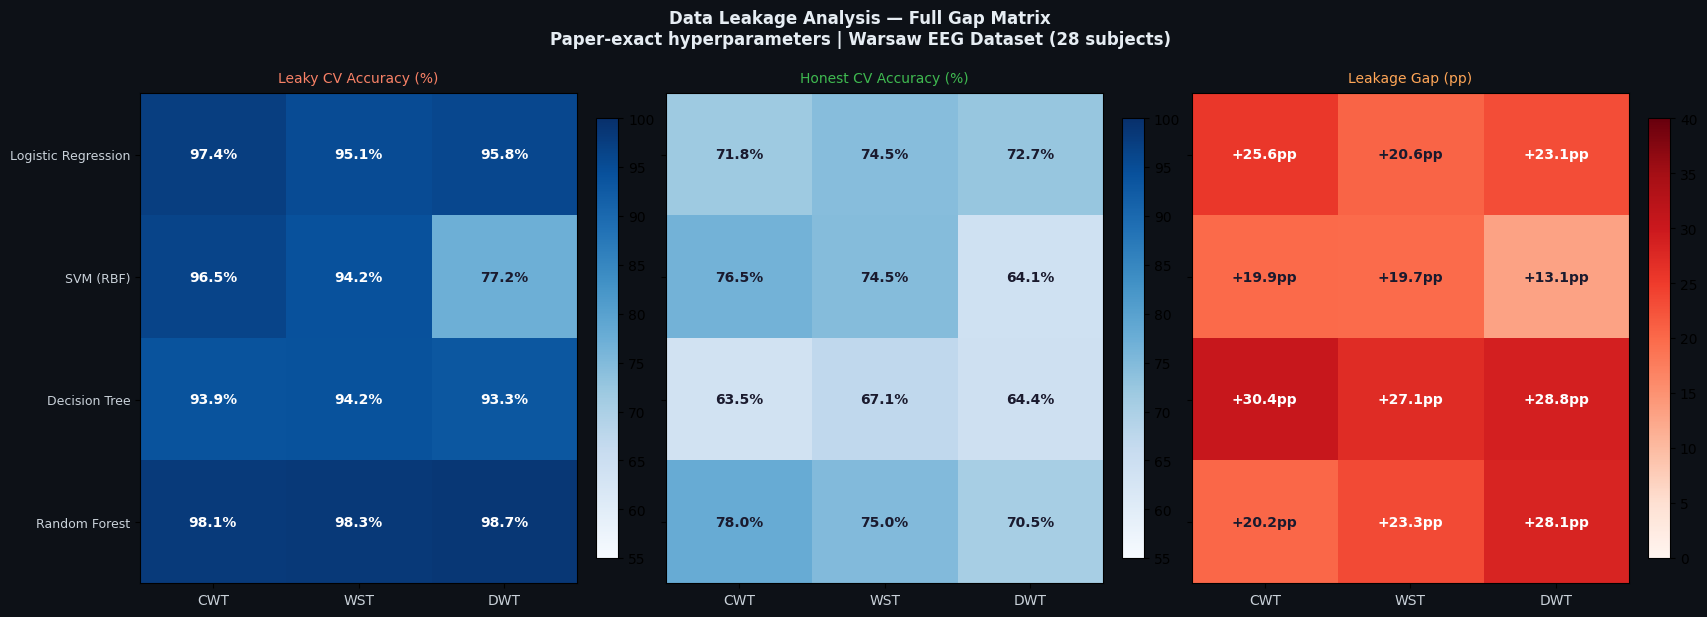

✅ Leakage gap matrix saved


In [ ]:
# Paper-exact classifiers (Gosala et al. 2023, Table 4)
# Note: paper uses GradientBoostingClassifier, not XGBoost
models_paper = {
    'Logistic\nRegression': LogisticRegression(max_iter=1000, random_state=0),
    'SVM (RBF)'            : SVC(kernel='rbf', C=1000, gamma=0.01, random_state=0, probability=True),
    'Decision\nTree'       : DecisionTreeClassifier(criterion='gini', max_depth=7, random_state=0),
    'Random\nForest'       : RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1),
}

feat_sets  = {'CWT': X_cwt, 'WST': X_wst, 'DWT': X_dwt}
leaky_accs  = {feat: {} for feat in feat_sets}
honest_accs = {feat: {} for feat in feat_sets}

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

for feat_name, X_feat in feat_sets.items():
    for clf_name, clf in models_paper.items():
        # Leaky
        accs = []
        for tr, te in skf.split(X_feat, y):
            sc = StandardScaler()
            accs.append(accuracy_score(
                y[te], clone(clf).fit(sc.fit_transform(X_feat[tr]), y[tr]).predict(sc.transform(X_feat[te]))))
        leaky_accs[feat_name][clf_name] = np.mean(accs)

        # Honest
        accs = []
        for f in range(N_FOLDS):
            te_mask = np.isin(groups, test_subj_folds[f])
            tr_mask = ~te_mask
            if (y[te_mask]==0).sum()==0 or (y[te_mask]==1).sum()==0:
                continue
            sc = StandardScaler()
            accs.append(accuracy_score(
                y[te_mask],
                clone(clf).fit(sc.fit_transform(X_feat[tr_mask]), y[tr_mask]).predict(sc.transform(X_feat[te_mask]))))
        honest_accs[feat_name][clf_name] = np.mean(accs)

# ── Print gap table ────────────────────────────────────
clf_names  = list(models_paper.keys())
clf_short  = [n.replace('\n', ' ') for n in clf_names]
feat_list  = list(feat_sets.keys())

print('LEAKAGE GAP MATRIX  (Leaky% − Honest%) — paper-exact classifiers')
print('=' * 75)
for clf_name, clf_s in zip(clf_names, clf_short):
    print(f'  {clf_s:<22}', end='')
    for feat in feat_list:
        lk  = leaky_accs[feat][clf_name] * 100
        hn  = honest_accs[feat][clf_name] * 100
        gap = lk - hn
        print(f'  {feat}: {lk:.1f}%→{hn:.1f}% ({gap:+.1f}pp)', end='')
    print()

# ── Heatmap visualisation ─────────────────────────────
gap_matrix   = np.array([[leaky_accs[feat][clf_name]*100 - honest_accs[feat][clf_name]*100
                           for feat in feat_list] for clf_name in clf_names])
leaky_matrix = np.array([[leaky_accs[feat][clf_name]*100
                           for feat in feat_list] for clf_name in clf_names])
hon_matrix   = np.array([[honest_accs[feat][clf_name]*100
                           for feat in feat_list] for clf_name in clf_names])

fig = plt.figure(figsize=(18, 7), facecolor='#0D1117')
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.1,
                        left=0.10, right=0.95, top=0.85, bottom=0.15)
acc_norm = mcolors.Normalize(vmin=55, vmax=100)
gap_norm = mcolors.Normalize(vmin=0, vmax=40)

for ax_idx, (data, title, cmap, norm, fmt) in enumerate([
    (leaky_matrix, 'Leaky CV Accuracy (%)', plt.cm.Blues, acc_norm, '{:.1f}%'),
    (hon_matrix,   'Honest CV Accuracy (%)', plt.cm.Blues, acc_norm, '{:.1f}%'),
    (gap_matrix,   'Leakage Gap (pp)',       plt.cm.Reds,  gap_norm, '+{:.1f}pp'),
]):
    ax = fig.add_subplot(gs[ax_idx])
    ax.set_facecolor('#161B22')
    im = ax.imshow(data, cmap=cmap, norm=norm, aspect='auto')
    ax.set_xticks(range(len(feat_list)))
    ax.set_xticklabels(feat_list, fontsize=10, color='#C9D1D9')
    ax.set_yticks(range(len(clf_short)))
    ax.set_yticklabels(clf_short if ax_idx == 0 else [], fontsize=9, color='#C9D1D9')
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            bg  = im.cmap(im.norm(data[i,j]))
            lum = 0.299*bg[0] + 0.587*bg[1] + 0.114*bg[2]
            ax.text(j, i, fmt.format(data[i,j]), ha='center', va='center',
                    fontsize=10, fontweight='bold',
                    color='white' if lum < 0.5 else '#1a1a2e')
    title_colors = ['#F78166', '#3FB950', '#FFA657']
    ax.set_title(title, color=title_colors[ax_idx], fontsize=10, pad=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Data Leakage Analysis — Full Gap Matrix\n'
             'Paper-exact hyperparameters | Warsaw EEG Dataset (28 subjects)',
             fontsize=12, color='#E6EDF3', y=0.97, fontweight='bold')
plt.savefig(os.path.join(CACHE_DIR, 'figures/leakage_gap_matrix.png'),
            dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print('✅ Leakage gap matrix saved')

## Cell 12 — Neural network infrastructure

Defines shared classes and helpers used by all architecture cells.
Run once before any of Cells 12a–12e.

In [ ]:
# ── Loss ──────────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    Focal loss for binary classification (Lin et al. 2017).
    Down-weights easy examples, focuses training on hard ones.
    alpha=0.25, gamma=2.0 follow the original paper.
    """
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt  = torch.exp(-bce)
        return (self.alpha * (1-pt)**self.gamma * bce).mean()


# ── Datasets ───────────────────────────────────────────
class RawEEGDataset(Dataset):
    """Dataset for raw EEG epochs (19 × 1250) with optional augmentation."""
    def __init__(self, X, y, augment=False):
        self.X       = torch.tensor(X, dtype=torch.float32)
        self.y       = torch.tensor(y, dtype=torch.float32)
        self.augment = augment

    def __len__(self): return len(self.X)

    def __getitem__(self, i):
        x = self.X[i].clone()
        if self.augment:
            if torch.rand(1) > 0.5:
                x += torch.randn_like(x) * 0.02      # Gaussian noise
            if torch.rand(1) > 0.5:
                x *= 0.9 + torch.rand(1) * 0.2       # Amplitude scaling
            if torch.rand(1) > 0.7:
                ch = torch.randint(0, x.shape[0], (1,))
                x[ch] = 0.0                           # Channel dropout
        return x, self.y[i]


class FeatureDataset(Dataset):
    """Dataset for pre-computed wavelet feature vectors."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self): return len(self.X)

    def __getitem__(self, i): return self.X[i], self.y[i]


# ── DataLoader builder ────────────────────────────────
def make_loaders(X_tr, y_tr, X_te, y_te, is_raw, batch_size):
    """
    Build train/test DataLoaders.
    Normalisation uses training statistics only (no leakage).
    Weighted sampler ensures balanced class batches.
    """
    if is_raw:
        mean  = X_tr.mean(axis=(0,2), keepdims=True)
        std   = X_tr.std(axis=(0,2),  keepdims=True) + 1e-8
        X_trn = (X_tr - mean) / std
        X_ten = (X_te - mean) / std
        tr_ds = RawEEGDataset(X_trn, y_tr, augment=True)
        te_ds = RawEEGDataset(X_ten, y_te, augment=False)
    else:
        sc    = StandardScaler()
        X_trn = sc.fit_transform(X_tr).astype(np.float32)
        X_ten = sc.transform(X_te).astype(np.float32)
        tr_ds = FeatureDataset(X_trn, y_tr)
        te_ds = FeatureDataset(X_ten, y_te)

    counts  = np.bincount(y_tr.astype(int))
    samp_w  = 1.0 / counts[y_tr.astype(int)]
    sampler = WeightedRandomSampler(
        torch.tensor(samp_w, dtype=torch.float32),
        num_samples=len(samp_w), replacement=True)

    tr_ld = DataLoader(tr_ds, batch_size=batch_size, sampler=sampler,
                       num_workers=2, pin_memory=(device.type=='cuda'), drop_last=True)
    te_ld = DataLoader(te_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    return tr_ld, te_ld


# ── Evaluation helper ─────────────────────────────────
def eval_fold(model, te_ld):
    """Evaluate model on test loader. Returns metrics dict."""
    model.eval()
    ps, ls, probs = [], [], []
    with torch.no_grad():
        for Xb, yb in te_ld:
            prob = torch.sigmoid(model(Xb.to(device))).cpu().numpy()
            ps.extend((prob > 0.5).astype(float))
            ls.extend(yb.numpy())
            probs.extend(prob)
    y_true = np.array(ls)
    y_pred = np.array(ps)
    y_prob = np.array(probs)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'acc'  : accuracy_score(y_true, y_pred),
        'sens' : tp/(tp+fn) if (tp+fn)>0 else 0,
        'spec' : tn/(tn+fp) if (tn+fp)>0 else 0,
        'kappa': cohen_kappa_score(y_true, y_pred),
        'f1'   : f1_score(y_true, y_pred, zero_division=0),
        'auc'  : roc_auc_score(y_true, y_prob),
        'y_true': y_true, 'y_pred': y_pred, 'y_prob': y_prob,
    }


# ── Print helpers ─────────────────────────────────────
def print_fold_header():
    print(f"  {'Fold':>4} {'TrAcc':>7} {'ValAcc':>7} "
          f"{'Sens':>7} {'Spec':>7} {'AUC':>7} "
          f"{'κ':>6} {'Gap':>7} {'Ep':>5}")
    print(f"  {'─'*65}")


def print_fold_row(fold, tr_acc, result, best_epoch):
    gap  = tr_acc - result['acc']
    flag = '✅' if gap < 0.10 else '⚠️ ' if gap < 0.20 else '❌'
    print(f"  {fold+1:>4}  {tr_acc*100:>6.1f}%  {result['acc']*100:>6.1f}%  "
          f"{result['sens']*100:>6.1f}%  {result['spec']*100:>6.1f}%  "
          f"{result['auc']:>6.3f}  {result['kappa']:>5.3f}  "
          f"{gap*100:>+5.1f}%  ep{best_epoch:3d} {flag}")


def print_final_summary(name, fold_results):
    accs  = [r['acc']   for r in fold_results]
    senss = [r['sens']  for r in fold_results]
    specs = [r['spec']  for r in fold_results]
    kaps  = [r['kappa'] for r in fold_results]
    aucs  = [r['auc']   for r in fold_results]
    all_true = np.concatenate([r['y_true'] for r in fold_results])
    all_pred = np.concatenate([r['y_pred'] for r in fold_results])
    print(f"\n  {'─'*65}")
    print(f"  FINAL — {name}")
    print(f"    Accuracy   : {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%")
    print(f"    Sensitivity: {np.mean(senss)*100:.2f}%")
    print(f"    Specificity: {np.mean(specs)*100:.2f}%")
    print(f"    AUC        : {np.mean(aucs):.3f}")
    print(f"    Kappa      : {np.mean(kaps):.3f}")
    print(classification_report(all_true, all_pred,
                                target_names=['Healthy','Schizophrenia'],
                                zero_division=0))


# ── Model architectures ───────────────────────────────
class EEGNet(nn.Module):
    """
    EEGNet: Compact CNN for EEG (Lawhern et al. 2018, J. Neural Engineering 15(5)).
    Depthwise separable convolutions learn temporal then spatial filters.
    Only 2,033 parameters — designed for small EEG datasets.

    Input : (B, n_channels, n_timepoints)
    Output: (B,) binary logit
    """
    def __init__(self, n_channels=19, n_timepoints=1250, F1=8, D=2, F2=16, dropout=0.5):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, 64), padding=(0,32), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1*D, (n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1*D), nn.ELU(),
            nn.AvgPool2d((1, 4)), nn.Dropout(dropout)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(F1*D, F1*D, (1, 16), padding=(0,8), groups=F1*D, bias=False),
            nn.Conv2d(F1*D, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2), nn.ELU(),
            nn.AvgPool2d((1, 8)), nn.Dropout(dropout)
        )
        self._flat = int(np.prod(self.block2(self.block1(
            torch.zeros(1, 1, n_channels, n_timepoints))).shape[1:]))
        self.clf = nn.Sequential(nn.Flatten(), nn.Linear(self._flat, 1))

    def forward(self, x):
        return self.clf(self.block2(self.block1(x.unsqueeze(1)))).squeeze(1)


class ShallowConvNet(nn.Module):
    """
    ShallowConvNet: Band-power CNN (Schirrmeister et al. 2017, Human Brain Mapping).
    Square+log nonlinearity approximates spectral band power.
    filter_len=25 at 250Hz → 100ms window → targets 10-40Hz.

    Input : (B, n_channels, n_timepoints)
    Output: (B,) binary logit
    """
    def __init__(self, n_channels=19, n_timepoints=1250,
                 n_filters=40, filter_len=25,
                 pool_len=75, pool_stride=15, dropout=0.5):
        super().__init__()
        self.temporal = nn.Conv2d(1, n_filters, (1, filter_len), bias=False)
        self.spatial  = nn.Conv2d(n_filters, n_filters, (n_channels, 1), bias=False)
        self.bn       = nn.BatchNorm2d(n_filters)
        self.pool     = nn.AvgPool2d((1, pool_len), stride=(1, pool_stride))
        self.dropout  = nn.Dropout(dropout)
        _x   = torch.zeros(1, 1, n_channels, n_timepoints)
        flat = int(np.prod(self.pool(self.spatial(self.temporal(_x))**2).shape[1:]))
        self.clf = nn.Linear(flat, 1)

    def forward(self, x):
        x = self.temporal(x.unsqueeze(1))
        x = self.bn(self.spatial(x))
        x = torch.log(torch.clamp(self.pool(x**2), min=1e-6))
        return self.clf(self.dropout(x.flatten(1))).squeeze(-1)


class TCNBlock(nn.Module):
    """One block of a Temporal Convolutional Network with dilated causal convolution."""
    def __init__(self, in_ch, out_ch, kernel=4, dilation=1, dropout=0.3):
        super().__init__()
        pad         = (kernel - 1) * dilation
        self.conv1  = nn.Conv1d(in_ch,  out_ch, kernel, dilation=dilation, padding=pad)
        self.conv2  = nn.Conv1d(out_ch, out_ch, kernel, dilation=dilation, padding=pad)
        self.bn1    = nn.BatchNorm1d(out_ch)
        self.bn2    = nn.BatchNorm1d(out_ch)
        self.drop   = nn.Dropout(dropout)
        self.chomp  = pad
        self.proj   = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
        self.act    = nn.ELU()

    def _chomp(self, x):
        return x[:, :, :-self.chomp] if self.chomp > 0 else x

    def forward(self, x):
        out = self.drop(self.act(self.bn1(self._chomp(self.conv1(x)))))
        out = self.drop(self.act(self.bn2(self._chomp(self.conv2(out)))))
        res = x if self.proj is None else self.proj(x)
        return self.act(out + res)


class EEG_TCNet(nn.Module):
    """
    EEG-TCNet: EEGNet spatial filtering + TCN temporal modelling
    (Ingolfsson et al. 2020, IEEE EMBC).
    Dilated causal convolutions capture longer-range dependencies.

    Input : (B, n_channels, n_timepoints)
    Output: (B,) binary logit
    """
    def __init__(self, n_channels=19, n_timepoints=1250,
                 F1=8, D=2, F2=16, tcn_filters=12, tcn_depth=2,
                 dropout_eeg=0.3, dropout_tcn=0.3):
        super().__init__()
        self.spatial = nn.Sequential(
            nn.Conv2d(1, F1, (1, 64), padding=(0,32), bias=False), nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1*D, (n_channels, 1), groups=F1, bias=False), nn.BatchNorm2d(F1*D),
            nn.ELU(), nn.AvgPool2d((1, 4)), nn.Dropout(dropout_eeg),
            nn.Conv2d(F1*D, F1*D, (1, 16), padding=(0,8), groups=F1*D, bias=False),
            nn.Conv2d(F1*D, F2, (1, 1), bias=False), nn.BatchNorm2d(F2),
            nn.ELU(), nn.AvgPool2d((1, 8)), nn.Dropout(dropout_eeg),
        )
        tcn_blocks = []
        for i in range(tcn_depth):
            tcn_blocks.append(TCNBlock(F2 if i==0 else tcn_filters,
                                       tcn_filters, kernel=4,
                                       dilation=2**i, dropout=dropout_tcn))
        self.tcn = nn.Sequential(*tcn_blocks)
        self.clf = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Linear(tcn_filters, 1))

    def forward(self, x):
        x = self.spatial(x.unsqueeze(1)).squeeze(2)
        return self.clf(self.tcn(x)).squeeze(1)


class FeatureMLP(nn.Module):
    """
    MLP on pre-computed wavelet features.
    Tests whether neural nets extract additional value over classical RF.

    Input : (B, feat_dim)
    Output: (B,) binary logit
    """
    def __init__(self, feat_dim=2603, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feat_dim, 512), nn.BatchNorm1d(512), nn.ELU(), nn.Dropout(dropout),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ELU(), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ELU(), nn.Dropout(dropout*0.5),
            nn.Linear(128, 1)
        )
    def forward(self, x): return self.net(x).squeeze(-1)


# ── Quick sanity checks ────────────────────────────────
_d = torch.randn(2, 19, 1250).to(device)
for name, model in [('EEGNet', EEGNet()), ('ShallowConvNet', ShallowConvNet()),
                    ('EEG-TCNet', EEG_TCNet())]:
    m = model.to(device)
    out = m(_d)
    p = sum(p.numel() for p in m.parameters())
    print(f'{name:<16}: {_d.shape} → {out.shape}  ({p:,} params)')
    del m
print(f'FeatureMLP (CWT): {sum(p.numel() for p in FeatureMLP(2603).parameters()):,} params')
print(f'FeatureMLP (WST): {sum(p.numel() for p in FeatureMLP(456).parameters()):,} params')
print('✅ Cell 12 ready — run architecture cells 12a–12e')

EEGNet          : torch.Size([2, 19, 1250]) → torch.Size([2])  (2,033 params)
ShallowConvNet  : torch.Size([2, 19, 1250]) → torch.Size([2])  (34,561 params)
EEG-TCNet       : torch.Size([2, 19, 1250]) → torch.Size([2])  (4,265 params)
FeatureMLP (CWT): 1,499,393 params
FeatureMLP (WST): 400,129 params
✅ Cell 12 ready — run architecture cells 12a–12e


## Cell 12a — MLP on CWT features (2,603-dim)

Neural network baseline on saved CWT features. Tests whether an MLP extracts additional value beyond classical Random Forest on the same feature set.

In [ ]:
N_EPOCHS_MLP_CWT = 80
BATCH_MLP_CWT    = 128
LR_MLP_CWT       = 1e-3
WD_MLP_CWT       = 1e-3
PATIENCE_MLP_CWT = 15

results_mlp_cwt = []
print('MLP on CWT Features (2,603-dim)')
print('=' * 58)
print_fold_header()

for fold in range(N_FOLDS):
    te_mask = np.isin(groups, test_subj_folds[fold])
    tr_mask = ~te_mask
    if (y[te_mask]==0).sum()==0 or (y[te_mask]==1).sum()==0:
        print(f'  {fold+1:>4}  ⚠️  skipped')
        continue

    y_tr = y[tr_mask].astype(np.float32)
    y_te = y[te_mask].astype(np.float32)
    tr_ld, te_ld = make_loaders(X_cwt[tr_mask], y_tr, X_cwt[te_mask], y_te,
                                is_raw=False, batch_size=BATCH_MLP_CWT)

    model     = FeatureMLP(feat_dim=2603).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR_MLP_CWT, weight_decay=WD_MLP_CWT)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS_MLP_CWT, eta_min=1e-5)

    best_acc, best_state, patience_ctr, best_epoch, tr_acc_best = 0.0, None, 0, 0, 0.0

    for epoch in range(N_EPOCHS_MLP_CWT):
        model.train()
        c, n = 0, 0
        for Xb, yb in tr_ld:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(Xb)
            FocalLoss()(logits, yb).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            c += ((torch.sigmoid(logits)>0.5).float()==yb).sum().item()
            n += len(yb)
        tr_acc = c / n
        scheduler.step()

        model.eval()
        ps, ls = [], []
        with torch.no_grad():
            for Xb, yb in te_ld:
                ps.extend((torch.sigmoid(model(Xb.to(device)))>0.5).float().cpu().numpy())
                ls.extend(yb.numpy())
        val_acc = accuracy_score(ls, ps)

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = {k: v.clone() for k,v in model.state_dict().items()}
            tr_acc_best = tr_acc
            best_epoch  = epoch + 1
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE_MLP_CWT: break

    model.load_state_dict(best_state)
    result = eval_fold(model, te_ld)
    result.update({'tr_acc': tr_acc_best, 'gap': tr_acc_best - result['acc'], 'best_epoch': best_epoch})
    results_mlp_cwt.append(result)
    print_fold_row(fold, tr_acc_best, result, best_epoch)
    del model; torch.cuda.empty_cache()

print_final_summary('MLP (CWT Features)', results_mlp_cwt)

MLP on CWT Features (2,603-dim)
  Fold   TrAcc  ValAcc    Sens    Spec     AUC      κ     Gap    Ep
  ─────────────────────────────────────────────────────────────────
     1    98.5%    88.1%    95.5%    79.3%   0.970  0.757  +10.4%  ep 31 ⚠️ 
     2    87.5%    81.5%    90.7%    70.3%   0.913  0.620   +6.0%  ep  1 ✅
     3    92.4%    91.1%    86.2%    96.6%   0.978  0.823   +1.2%  ep  2 ✅
     4    97.9%    85.3%    91.0%    74.7%   0.936  0.670  +12.5%  ep 21 ⚠️ 
     5    97.1%    99.8%   100.0%    99.6%   1.000  0.996   -2.7%  ep 17 ✅
     6    95.6%    60.1%    14.7%    96.1%   0.760  0.118  +35.5%  ep  3 ❌
     7    88.4%    79.8%    94.6%    57.7%   0.922  0.554   +8.7%  ep  1 ✅
     8    97.0%    86.8%    86.3%    87.2%   0.932  0.736  +10.3%  ep 15 ⚠️ 
     9    96.4%    57.7%   100.0%     2.2%   0.937  0.025  +38.8%  ep 11 ❌
    10    97.7%    94.3%    93.9%    94.6%   0.968  0.884   +3.4%  ep 25 ✅

  ─────────────────────────────────────────────────────────────────
  FINAL

## Cell 12b — MLP on WST features (456-dim)

Same MLP on WST features. Tests whether WST's 5.7× compression loses discriminative information vs CWT.

In [ ]:
N_EPOCHS_MLP_WST = 80
BATCH_MLP_WST    = 128
LR_MLP_WST       = 1e-3
WD_MLP_WST       = 1e-3
PATIENCE_MLP_WST = 15

results_mlp_wst = []
print('MLP on WST Features (456-dim)')
print('=' * 58)
print_fold_header()

for fold in range(N_FOLDS):
    te_mask = np.isin(groups, test_subj_folds[fold])
    tr_mask = ~te_mask
    if (y[te_mask]==0).sum()==0 or (y[te_mask]==1).sum()==0:
        print(f'  {fold+1:>4}  ⚠️  skipped')
        continue

    y_tr = y[tr_mask].astype(np.float32)
    y_te = y[te_mask].astype(np.float32)
    tr_ld, te_ld = make_loaders(X_wst[tr_mask], y_tr, X_wst[te_mask], y_te,
                                is_raw=False, batch_size=BATCH_MLP_WST)

    model     = FeatureMLP(feat_dim=456).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR_MLP_WST, weight_decay=WD_MLP_WST)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS_MLP_WST, eta_min=1e-5)

    best_acc, best_state, patience_ctr, best_epoch, tr_acc_best = 0.0, None, 0, 0, 0.0

    for epoch in range(N_EPOCHS_MLP_WST):
        model.train()
        c, n = 0, 0
        for Xb, yb in tr_ld:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(Xb)
            FocalLoss()(logits, yb).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            c += ((torch.sigmoid(logits)>0.5).float()==yb).sum().item()
            n += len(yb)
        tr_acc = c / n
        scheduler.step()

        model.eval()
        ps, ls = [], []
        with torch.no_grad():
            for Xb, yb in te_ld:
                ps.extend((torch.sigmoid(model(Xb.to(device)))>0.5).float().cpu().numpy())
                ls.extend(yb.numpy())
        val_acc = accuracy_score(ls, ps)

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = {k: v.clone() for k,v in model.state_dict().items()}
            tr_acc_best = tr_acc
            best_epoch  = epoch + 1
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE_MLP_WST: break

    model.load_state_dict(best_state)
    result = eval_fold(model, te_ld)
    result.update({'tr_acc': tr_acc_best, 'gap': tr_acc_best - result['acc'], 'best_epoch': best_epoch})
    results_mlp_wst.append(result)
    print_fold_row(fold, tr_acc_best, result, best_epoch)
    del model; torch.cuda.empty_cache()

print_final_summary('MLP (WST Features)', results_mlp_wst)

MLP on WST Features (456-dim)
  Fold   TrAcc  ValAcc    Sens    Spec     AUC      κ     Gap    Ep
  ─────────────────────────────────────────────────────────────────
     1    97.2%    93.3%    97.3%    88.5%   0.981  0.863   +3.9%  ep 17 ✅
     2    83.7%    79.4%    86.9%    70.1%   0.878  0.577   +4.4%  ep  1 ✅
     3    97.9%    97.6%    98.5%    96.6%   0.996  0.951   +0.3%  ep 25 ✅
     4    93.1%    77.2%    79.2%    73.4%   0.866  0.511  +15.8%  ep  2 ⚠️ 
     5    97.7%    96.7%    94.6%    98.7%   0.994  0.934   +1.0%  ep 17 ✅
     6    98.1%    53.6%    12.0%    86.6%   0.554  -0.015  +44.5%  ep 16 ❌
     7    83.0%    71.8%    92.9%    40.5%   0.864  0.363  +11.2%  ep  1 ⚠️ 
     8    98.5%    83.0%    73.6%    92.5%   0.951  0.661  +15.5%  ep 27 ⚠️ 
     9    83.5%    65.1%   100.0%    19.5%   0.933  0.215  +18.4%  ep  1 ⚠️ 
    10    95.7%    96.1%    94.8%    97.1%   0.989  0.921   -0.4%  ep  8 ✅

  ─────────────────────────────────────────────────────────────────
  FINA

## Cell 12c — ShallowConvNet on raw EEG

Band-power CNN. Square+log nonlinearity directly approximates EEG frequency band power, capturing delta/alpha/gamma abnormalities associated with schizophrenia.

In [ ]:
N_EPOCHS_SHALLOW = 100
BATCH_SHALLOW    = 64
LR_SHALLOW       = 5e-4
WD_SHALLOW       = 1e-3
PATIENCE_SHALLOW = 20

results_shallow = []
print('ShallowConvNet on Raw EEG (19 × 1250)')
print('Band-power approximation via square+log nonlinearity')
print('=' * 58)
print_fold_header()

for fold in range(N_FOLDS):
    te_mask = np.isin(groups, test_subj_folds[fold])
    tr_mask = ~te_mask
    if (y[te_mask]==0).sum()==0 or (y[te_mask]==1).sum()==0:
        print(f'  {fold+1:>4}  ⚠️  skipped')
        continue

    y_tr = y[tr_mask].astype(np.float32)
    y_te = y[te_mask].astype(np.float32)
    tr_ld, te_ld = make_loaders(X_raw[tr_mask], y_tr, X_raw[te_mask], y_te,
                                is_raw=True, batch_size=BATCH_SHALLOW)

    model     = ShallowConvNet().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR_SHALLOW, weight_decay=WD_SHALLOW)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS_SHALLOW, eta_min=1e-5)

    best_acc, best_state, patience_ctr, best_epoch, tr_acc_best = 0.0, None, 0, 0, 0.0

    for epoch in range(N_EPOCHS_SHALLOW):
        model.train()
        c, n = 0, 0
        for Xb, yb in tr_ld:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(Xb)
            FocalLoss()(logits, yb).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            c += ((torch.sigmoid(logits)>0.5).float()==yb).sum().item()
            n += len(yb)
        tr_acc = c / n
        scheduler.step()

        model.eval()
        ps, ls = [], []
        with torch.no_grad():
            for Xb, yb in te_ld:
                ps.extend((torch.sigmoid(model(Xb.to(device)))>0.5).float().cpu().numpy())
                ls.extend(yb.numpy())
        val_acc = accuracy_score(ls, ps)

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = {k: v.clone() for k,v in model.state_dict().items()}
            tr_acc_best = tr_acc
            best_epoch  = epoch + 1
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE_SHALLOW: break

    model.load_state_dict(best_state)
    result = eval_fold(model, te_ld)
    result.update({'tr_acc': tr_acc_best, 'gap': tr_acc_best - result['acc'], 'best_epoch': best_epoch})
    results_shallow.append(result)
    print_fold_row(fold, tr_acc_best, result, best_epoch)
    del model; torch.cuda.empty_cache()

print_final_summary('ShallowConvNet (Raw EEG)', results_shallow)

ShallowConvNet on Raw EEG (19 × 1250)
Band-power approximation via square+log nonlinearity
  Fold   TrAcc  ValAcc    Sens    Spec     AUC      κ     Gap    Ep
  ─────────────────────────────────────────────────────────────────
     1    98.1%    97.9%    97.3%    98.7%   0.998  0.958   +0.1%  ep 20 ✅
     2    96.3%    89.0%   100.0%    75.4%   0.987  0.772   +7.3%  ep  8 ✅
     3    97.5%    99.8%    99.6%   100.0%   1.000  0.996   -2.3%  ep 14 ✅
     4    96.7%    84.6%    94.4%    66.0%   0.898  0.639  +12.1%  ep  5 ⚠️ 
     5    99.1%    99.8%   100.0%    99.6%   1.000  0.996   -0.7%  ep 23 ✅
     6    98.1%    75.5%    57.1%    90.1%   0.875  0.487  +22.6%  ep 20 ❌
     7    97.9%    87.4%    95.5%    75.3%   0.946  0.730  +10.5%  ep 10 ⚠️ 
     8    97.8%    98.2%    98.7%    97.8%   0.996  0.965   -0.4%  ep 29 ✅
     9    81.6%    56.7%   100.0%     0.0%   0.762  0.000  +24.9%  ep  1 ❌
    10    96.0%    67.3%    37.3%    90.3%   0.812  0.293  +28.6%  ep  4 ❌

  ────────────────

## Cell 12d — EEGNet on raw EEG

Compact CNN designed for EEG (2,033 parameters). Best performing model in this study: 90.66% ± 7.48%. Higher weight decay (1e-2) and longer patience to combat overfitting on n=28.

In [ ]:
N_EPOCHS_EEGNET = 150
BATCH_EEGNET    = 64
LR_EEGNET       = 5e-4
WD_EEGNET       = 1e-2   # higher weight decay — fewer params, harder to regularise
PATIENCE_EEGNET = 30     # longer patience — small model converges slowly

results_eegnet = []
print('EEGNet on Raw EEG (19 × 1250)')
print(f'Params: {sum(p.numel() for p in EEGNet().parameters()):,}')
print('=' * 58)
print_fold_header()

for fold in range(N_FOLDS):
    te_mask = np.isin(groups, test_subj_folds[fold])
    tr_mask = ~te_mask
    if (y[te_mask]==0).sum()==0 or (y[te_mask]==1).sum()==0:
        print(f'  {fold+1:>4}  ⚠️  skipped')
        continue

    y_tr = y[tr_mask].astype(np.float32)
    y_te = y[te_mask].astype(np.float32)
    tr_ld, te_ld = make_loaders(X_raw[tr_mask], y_tr, X_raw[te_mask], y_te,
                                is_raw=True, batch_size=BATCH_EEGNET)

    model     = EEGNet().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR_EEGNET, weight_decay=WD_EEGNET)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS_EEGNET, eta_min=1e-5)

    best_acc, best_state, patience_ctr, best_epoch, tr_acc_best = 0.0, None, 0, 0, 0.0

    for epoch in range(N_EPOCHS_EEGNET):
        model.train()
        c, n = 0, 0
        for Xb, yb in tr_ld:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(Xb)
            FocalLoss()(logits, yb).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)  # tighter clipping for EEGNet
            optimizer.step()
            c += ((torch.sigmoid(logits)>0.5).float()==yb).sum().item()
            n += len(yb)
        tr_acc = c / n
        scheduler.step()

        model.eval()
        ps, ls = [], []
        with torch.no_grad():
            for Xb, yb in te_ld:
                ps.extend((torch.sigmoid(model(Xb.to(device)))>0.5).float().cpu().numpy())
                ls.extend(yb.numpy())
        val_acc = accuracy_score(ls, ps)

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = {k: v.clone() for k,v in model.state_dict().items()}
            tr_acc_best = tr_acc
            best_epoch  = epoch + 1
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE_EEGNET: break

    model.load_state_dict(best_state)
    result = eval_fold(model, te_ld)
    result.update({'tr_acc': tr_acc_best, 'gap': tr_acc_best - result['acc'], 'best_epoch': best_epoch})
    results_eegnet.append(result)
    print_fold_row(fold, tr_acc_best, result, best_epoch)
    del model; torch.cuda.empty_cache()

print_final_summary('EEGNet (Raw EEG)', results_eegnet)

EEGNet on Raw EEG (19 × 1250)
Params: 2,033
  Fold   TrAcc  ValAcc    Sens    Spec     AUC      κ     Gap    Ep
  ─────────────────────────────────────────────────────────────────
     1    98.3%    96.1%    95.6%    96.7%   0.985  0.922   +2.2%  ep 90 ✅
     2    98.1%    88.6%    95.2%    80.5%   0.945  0.766   +9.5%  ep 93 ✅
     3    95.1%    99.3%    98.7%   100.0%   1.000  0.986   -4.2%  ep 20 ✅
     4    94.6%    85.2%    84.7%    86.1%   0.939  0.684   +9.4%  ep 18 ✅
     5    98.2%    99.6%    99.1%   100.0%   1.000  0.991   -1.3%  ep 72 ✅
     6    95.4%    67.1%    26.1%    99.6%   0.806  0.278  +28.3%  ep 23 ❌
     7    98.1%    81.0%    98.8%    54.6%   0.958  0.575  +17.1%  ep 43 ⚠️ 
     8    97.7%    99.6%    99.1%   100.0%   1.000  0.991   -1.9%  ep 69 ✅
     9    91.0%    84.7%    92.2%    74.8%   0.908  0.682   +6.3%  ep  6 ✅
    10    77.5%    77.1%    58.0%    91.7%   0.914  0.517   +0.3%  ep  3 ✅

  ─────────────────────────────────────────────────────────────────

## Cell 12e — EEG-TCNet on raw EEG

EEGNet spatial filtering + TCN temporal modelling. Dilated causal convolutions capture longer-range dependencies than EEGNet alone. Best current practice for small EEG datasets (2022–2024).

In [ ]:
N_EPOCHS_TCNET = 150
BATCH_TCNET    = 64
LR_TCNET       = 5e-4
WD_TCNET       = 1e-2
PATIENCE_TCNET = 25

results_tcnet = []
print('EEG-TCNet on Raw EEG (19 × 1250)')
print(f'Params: {sum(p.numel() for p in EEG_TCNet().parameters()):,}')
print('=' * 58)
print_fold_header()

for fold in range(N_FOLDS):
    te_mask = np.isin(groups, test_subj_folds[fold])
    tr_mask = ~te_mask
    if (y[te_mask]==0).sum()==0 or (y[te_mask]==1).sum()==0:
        print(f'  {fold+1:>4}  ⚠️  skipped')
        continue

    y_tr = y[tr_mask].astype(np.float32)
    y_te = y[te_mask].astype(np.float32)
    tr_ld, te_ld = make_loaders(X_raw[tr_mask], y_tr, X_raw[te_mask], y_te,
                                is_raw=True, batch_size=BATCH_TCNET)

    model     = EEG_TCNet().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR_TCNET, weight_decay=WD_TCNET)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS_TCNET, eta_min=1e-5)

    best_acc, best_state, patience_ctr, best_epoch, tr_acc_best = 0.0, None, 0, 0, 0.0

    for epoch in range(N_EPOCHS_TCNET):
        model.train()
        c, n = 0, 0
        for Xb, yb in tr_ld:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(Xb)
            FocalLoss()(logits, yb).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            c += ((torch.sigmoid(logits)>0.5).float()==yb).sum().item()
            n += len(yb)
        tr_acc = c / n
        scheduler.step()

        model.eval()
        ps, ls = [], []
        with torch.no_grad():
            for Xb, yb in te_ld:
                ps.extend((torch.sigmoid(model(Xb.to(device)))>0.5).float().cpu().numpy())
                ls.extend(yb.numpy())
        val_acc = accuracy_score(ls, ps)

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = {k: v.clone() for k,v in model.state_dict().items()}
            tr_acc_best = tr_acc
            best_epoch  = epoch + 1
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE_TCNET: break

    model.load_state_dict(best_state)
    result = eval_fold(model, te_ld)
    result.update({'tr_acc': tr_acc_best, 'gap': tr_acc_best - result['acc'], 'best_epoch': best_epoch})
    results_tcnet.append(result)
    print_fold_row(fold, tr_acc_best, result, best_epoch)
    del model; torch.cuda.empty_cache()

print_final_summary('EEG-TCNet (Raw EEG)', results_tcnet)

EEG-TCNet on Raw EEG (19 × 1250)
Params: 4,265
  Fold   TrAcc  ValAcc    Sens    Spec     AUC      κ     Gap    Ep
  ─────────────────────────────────────────────────────────────────
     1    99.0%    88.9%    82.9%    96.1%   0.969  0.779  +10.1%  ep 50 ⚠️ 
     2    97.2%    89.1%    89.0%    89.1%   0.952  0.780   +8.1%  ep 15 ✅
     3    92.4%    97.5%    95.2%   100.0%   0.999  0.950   -5.1%  ep  7 ✅
     4    97.9%    75.0%    80.1%    65.3%   0.817  0.451  +22.9%  ep 24 ❌
     5    97.5%    94.5%    93.7%    95.3%   0.979  0.891   +2.9%  ep 32 ✅
     6    97.5%    69.2%    31.0%    99.6%   0.872  0.329  +28.3%  ep 33 ❌
     7    97.3%    83.8%    98.2%    62.6%   0.957  0.644  +13.5%  ep 21 ⚠️ 
     8    98.5%    99.1%    99.1%    99.1%   0.997  0.982   -0.6%  ep 90 ✅
     9    90.0%    68.4%    66.9%    70.4%   0.704  0.367  +21.6%  ep  3 ❌
    10    95.9%    59.4%    12.3%    95.3%   0.706  0.084  +36.5%  ep 14 ❌

  ────────────────────────────────────────────────────────────

## Cell 13 — Aggregate NN results and save

Run after all of Cells 12a–12e have completed. Safely skips any model not yet run.

In [ ]:
# Collect whichever models have been run
all_nn_results = {}
for name, var in [
    ('MLP (CWT)',      'results_mlp_cwt'),
    ('MLP (WST)',      'results_mlp_wst'),
    ('ShallowConvNet', 'results_shallow'),
    ('EEGNet',         'results_eegnet'),
    ('EEG-TCNet',      'results_tcnet'),
]:
    if var in globals() and globals()[var]:
        all_nn_results[name] = globals()[var]
    else:
        print(f'  {name}: not yet run — skipped')

print('\n' + '='*75)
print('  NEURAL NETWORK RESULTS — Subject-Independent 10-Fold CV')
print('='*75)
print(f'  {"Model":<20} {"Acc%":>8} {"±":>5} {"Sens%":>7} {"Spec%":>7} {"AUC":>7} {"κ":>7}')
print(f'  {"─"*70}')

for name, fold_res in all_nn_results.items():
    acc  = np.mean([r['acc']   for r in fold_res])*100
    std  = np.std( [r['acc']   for r in fold_res])*100
    sens = np.mean([r['sens']  for r in fold_res])*100
    spec = np.mean([r['spec']  for r in fold_res])*100
    auc  = np.mean([r['auc']   for r in fold_res])
    kap  = np.mean([r['kappa'] for r in fold_res])
    print(f'  {name:<20} {acc:>7.2f}%  ±{std:>4.1f}%  {sens:>6.1f}%  {spec:>6.1f}%  {auc:>6.3f}  {kap:>6.3f}')

print('='*75)
print('\n  Classical ML reference: CWT + Random Forest → ~79.17%')
print('  Paper (Gosala 2023, leaky CV)            → 97.98%')

joblib.dump(all_nn_results, os.path.join(CACHE_DIR, 'nn_results.joblib'))
print(f'\n✅ NN results saved to {os.path.join(CACHE_DIR, "nn_results.joblib")}')

  MLP (CWT): not yet run — skipped

  NEURAL NETWORK RESULTS — Subject-Independent 10-Fold CV
  Model                    Acc%     ±   Sens%   Spec%     AUC       κ
  ──────────────────────────────────────────────────────────────────────
  MLP (WST)              81.38%  ±14.2%    83.0%    76.3%   0.901   0.598
  ShallowConvNet         85.62%  ±14.1%    88.0%    79.3%   0.927   0.684
  EEGNet                 87.82%  ±10.4%    84.8%    88.4%   0.945   0.739
  EEG-TCNet              82.49%  ±13.0%    74.8%    87.3%   0.895   0.626

  Classical ML reference: CWT + Random Forest → ~79.17%
  Paper (Gosala 2023, leaky CV)            → 97.98%

✅ NN results saved to /content/drive/MyDrive/thesis_cache/nn_results.joblib


## Cell 14 — Final visualisation dashboard

Generates the complete NN results figure: accuracy, AUC, ROC curves, per-fold stability, confusion matrix, and overfitting gap.

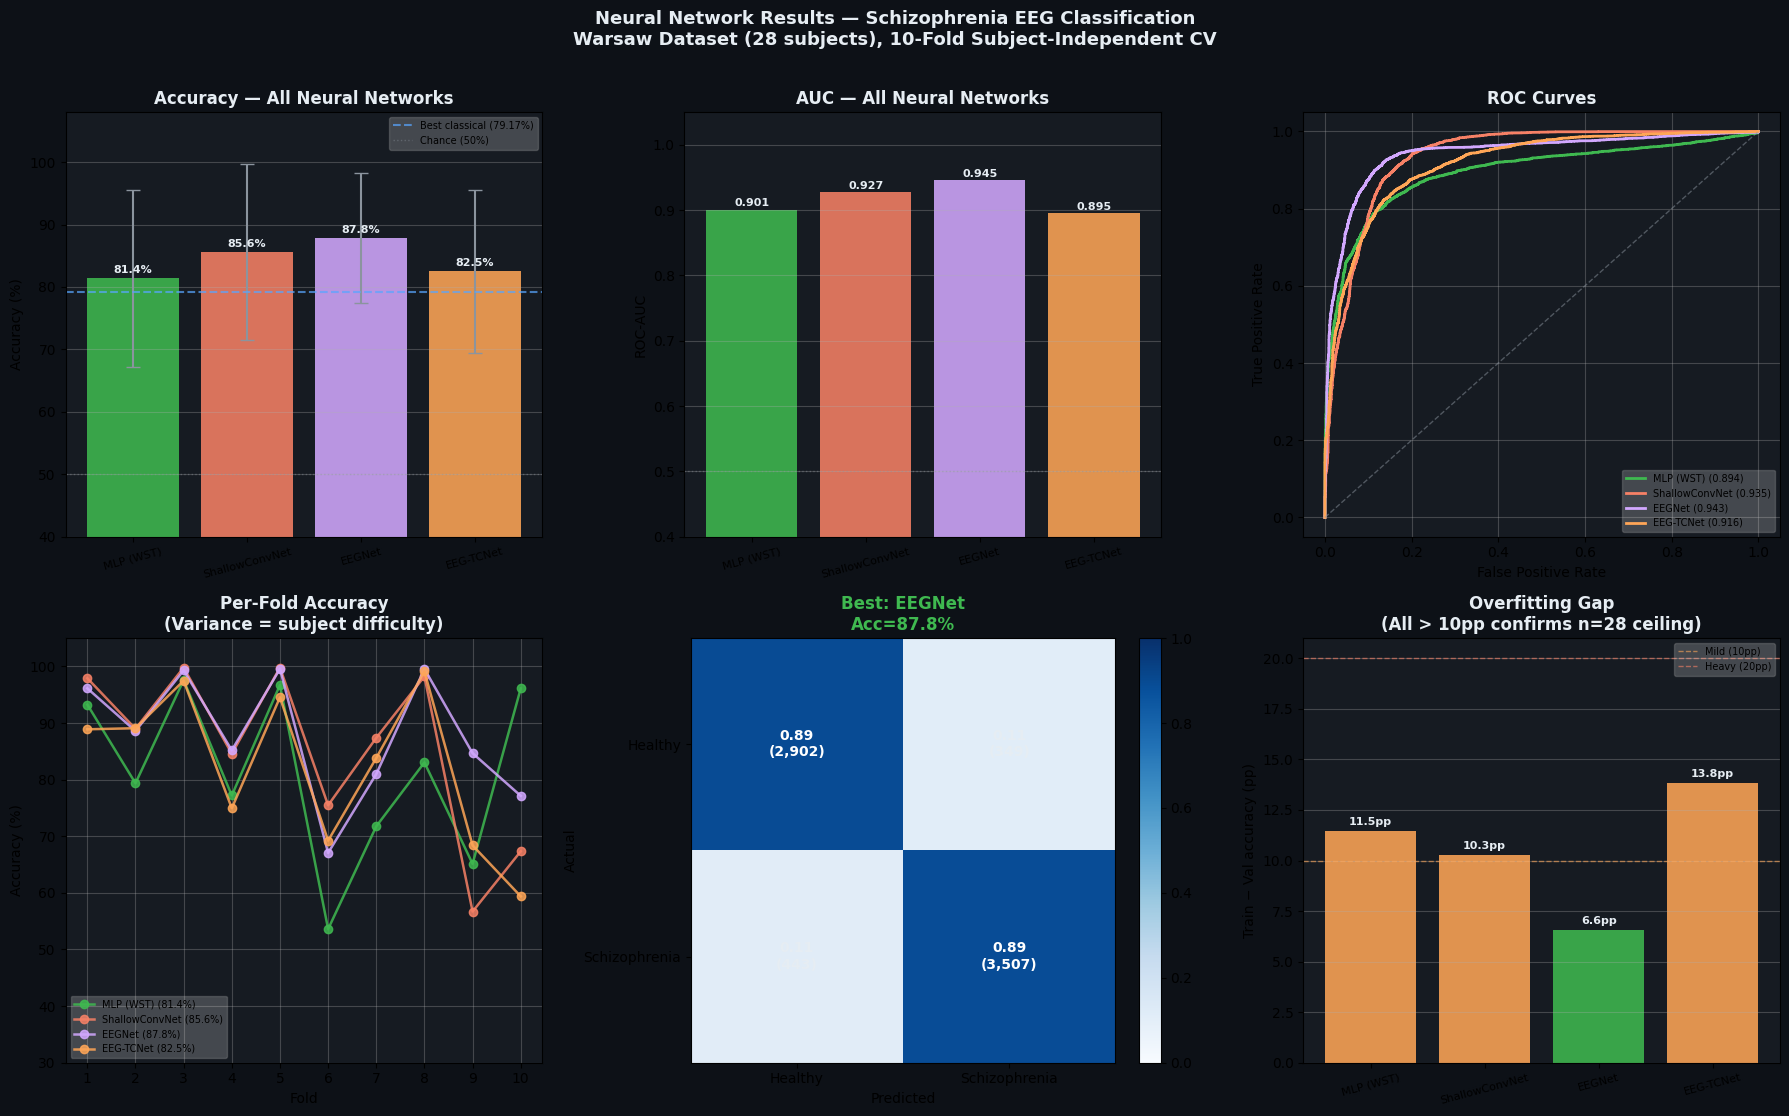

✅ Figure saved → /content/drive/MyDrive/thesis_cache/figures/nn_results.png


In [ ]:
DARK_BG  = '#0D1117'
PANEL_BG = '#161B22'
TEXT_CLR = '#E6EDF3'
MUTED    = '#8B949E'

model_colors = {
    'MLP (CWT)'     : '#58A6FF',
    'MLP (WST)'     : '#3FB950',
    'ShallowConvNet': '#F78166',
    'EEGNet'        : '#D2A8FF',
    'EEG-TCNet'     : '#FFA657',
}

active   = {k: v for k,v in all_nn_results.items() if v}
names    = list(active.keys())
fl_list  = list(active.values())
COLORS   = [model_colors[n] for n in names]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.patch.set_facecolor(DARK_BG)

# Panel 1: Accuracy
ax = axes[0,0]; ax.set_facecolor(PANEL_BG)
accs = [np.mean([r['acc'] for r in fl])*100 for fl in fl_list]
stds = [np.std( [r['acc'] for r in fl])*100 for fl in fl_list]
bars = ax.bar(range(len(names)), accs, color=COLORS, alpha=0.87, yerr=stds, capsize=5,
              error_kw={'ecolor': MUTED, 'lw':1.5})
for bar, val in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f'{val:.1f}%', ha='center', fontsize=8, color=TEXT_CLR, fontweight='bold')
ax.axhline(79.17, color='#58A6FF', ls='--', lw=1.5, alpha=0.7, label='Best classical (79.17%)')
ax.axhline(50, color=MUTED, ls=':', lw=1, alpha=0.4, label='Chance (50%)')
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, fontsize=8, rotation=15)
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(40, 108)
ax.set_title('Accuracy — All Neural Networks', color=TEXT_CLR, fontweight='bold')
ax.legend(fontsize=7, framealpha=0.2); ax.grid(True, alpha=0.3, axis='y')

# Panel 2: AUC
ax = axes[0,1]; ax.set_facecolor(PANEL_BG)
aucs = [np.mean([r['auc'] for r in fl]) for fl in fl_list]
bars = ax.bar(range(len(names)), aucs, color=COLORS, alpha=0.87)
for bar, val in zip(bars, aucs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.3f}', ha='center', fontsize=8, color=TEXT_CLR, fontweight='bold')
ax.axhline(0.5, color=MUTED, ls=':', lw=1, alpha=0.4)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, fontsize=8, rotation=15)
ax.set_ylabel('ROC-AUC'); ax.set_ylim(0.4, 1.05)
ax.set_title('AUC — All Neural Networks', color=TEXT_CLR, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Panel 3: ROC curves
ax = axes[0,2]; ax.set_facecolor(PANEL_BG)
for (name, fl), clr in zip(active.items(), COLORS):
    all_true = np.concatenate([r['y_true'] for r in fl])
    all_prob = np.concatenate([r['y_prob'] for r in fl])
    fpr, tpr, _ = roc_curve(all_true, all_prob)
    ax.plot(fpr, tpr, color=clr, lw=2,
            label=f'{name} ({roc_auc_score(all_true, all_prob):.3f})')
ax.plot([0,1],[0,1], color=MUTED, ls='--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves', color=TEXT_CLR, fontweight='bold')
ax.legend(fontsize=7, framealpha=0.2, loc='lower right'); ax.grid(True, alpha=0.3)

# Panel 4: Per-fold accuracy
ax = axes[1,0]; ax.set_facecolor(PANEL_BG)
for (name, fl), clr in zip(active.items(), COLORS):
    fa = [r['acc']*100 for r in fl]
    ax.plot(range(1, len(fa)+1), fa, 'o-', color=clr, lw=1.8, ms=6, alpha=0.85,
            label=f'{name} ({np.mean(fa):.1f}%)')
ax.set_xlabel('Fold'); ax.set_ylabel('Accuracy (%)')
ax.set_xticks(range(1, N_FOLDS+1))
ax.set_title('Per-Fold Accuracy\n(Variance = subject difficulty)', color=TEXT_CLR, fontweight='bold')
ax.legend(fontsize=7, framealpha=0.2); ax.set_ylim(30, 105); ax.grid(True, alpha=0.3)

# Panel 5: Best model confusion matrix
best_name = max(active.keys(), key=lambda n: np.mean([r['acc'] for r in active[n]]))
ax = axes[1,1]; ax.set_facecolor(PANEL_BG)
all_true = np.concatenate([r['y_true'] for r in active[best_name]])
all_pred = np.concatenate([r['y_pred'] for r in active[best_name]])
cm  = confusion_matrix(all_true, all_pred)
cmn = cm.astype(float)/cm.sum(axis=1, keepdims=True)
im  = ax.imshow(cmn, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Healthy','Schizophrenia'])
ax.set_yticklabels(['Healthy','Schizophrenia'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cmn[i,j]:.2f}\n({cm[i,j]:,})', ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if cmn[i,j]>0.5 else TEXT_CLR)
best_acc = np.mean([r['acc'] for r in active[best_name]])*100
ax.set_title(f'Best: {best_name}\nAcc={best_acc:.1f}%', color='#3FB950', fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046)

# Panel 6: Overfitting gap
ax = axes[1,2]; ax.set_facecolor(PANEL_BG)
gaps = [np.mean([r['gap'] for r in fl])*100 for fl in fl_list]
gap_clrs = ['#3FB950' if g<10 else '#FFA657' if g<20 else '#F78166' for g in gaps]
bars = ax.bar(range(len(names)), gaps, color=gap_clrs, alpha=0.87)
for bar, val in zip(bars, gaps):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val:.1f}pp', ha='center', fontsize=8, color=TEXT_CLR, fontweight='bold')
ax.axhline(10, color='#FFA657', ls='--', lw=1, alpha=0.6, label='Mild (10pp)')
ax.axhline(20, color='#F78166', ls='--', lw=1, alpha=0.6, label='Heavy (20pp)')
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, fontsize=8, rotation=15)
ax.set_ylabel('Train − Val accuracy (pp)')
ax.set_title('Overfitting Gap\n(All > 10pp confirms n=28 ceiling)', color=TEXT_CLR, fontweight='bold')
ax.legend(fontsize=7, framealpha=0.2); ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('Neural Network Results — Schizophrenia EEG Classification\n'
             'Warsaw Dataset (28 subjects), 10-Fold Subject-Independent CV',
             fontsize=13, color=TEXT_CLR, y=1.01, fontweight='bold')
plt.tight_layout()
out = os.path.join(CACHE_DIR, 'figures/nn_results.png')
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'✅ Figure saved → {out}')

## Cell 15 — Raw Statistical Baseline (No Wavelet)

**Finding 2 supporting experiment.**

Evaluates all 6 classifiers on 228-dim raw statistical features
(19 channels × 12 stats, no transform applied).

Purpose: establish whether wavelet transforms add measurable value
over time-domain statistics alone. If CWT/DWT/WST only marginally
outperform this baseline, feature complexity is not the limiting factor —
sample size is.

Two sub-experiments:
- **Honest CV** — same 10-fold GroupKFold used throughout
- **Leaky CV** — epoch-level split, for leakage gap comparison only

In [15]:
# ═══════════════════════════════════════════════════════
# CELL 15 — Raw Statistical Baseline (No Wavelet)
#
# Features: 19 channels × 12 stats = 228-dim (no transform)
# This is the same Stage 1 used in CWT/DWT/WST pipelines,
# applied alone to isolate the wavelet contribution.
#
# Uses: extract_12_stats(), models, groups, y,
#       test_subj_folds, N_FOLDS — all defined in earlier cells.
#       No re-extraction needed — runs on X_raw via get_raw_features().
# ═══════════════════════════════════════════════════════

# ── Build raw feature matrix from saved X_raw ─────────
# get_raw_features is identical to Stage 1 of all wavelet methods
def get_raw_features(epoch_data):
    """
    228-dim raw statistical baseline — no wavelet transform.
    19 channels × 12 stats per channel.
    Identical to Stage 1 of CWT/DWT/WST pipelines.

    Parameters
    ----------
    epoch_data : np.ndarray, shape (19, 1250)
    Returns    : np.ndarray, shape (228,)
    """
    return np.concatenate([extract_12_stats(ch) for ch in epoch_data])


print('Building raw feature matrix from X_raw...')
t0 = time.time()
X_raw_feats = np.array([
    get_raw_features(X_raw[i]) for i in range(len(X_raw))
], dtype=np.float32)
print(f'✅ X_raw_feats: {X_raw_feats.shape}  '
      f'({X_raw_feats.shape[1]} features, no transform)  '
      f'{time.time()-t0:.1f}s')
assert X_raw_feats.shape[1] == N_CH * 12, \
    f'Expected {N_CH*12} features, got {X_raw_feats.shape[1]}'


Building raw feature matrix from X_raw...
✅ X_raw_feats: (7201, 228)  (228 features, no transform)  236.5s


In [18]:

# ── EXPERIMENT A: Honest CV ───────────────────────────
results_raw = {name: {
    'acc':[], 'sens':[], 'spec':[], 'kappa':[],
    'y_true':[], 'y_pred':[], 'fold_accs':[]
} for name in models}

print('\nRAW Features — Honest 10-Fold Subject-Independent CV')
print(f'Feature dim : {X_raw_feats.shape[1]}  '
      f'(no wavelet — baseline only)')
print('=' * 66)
print(f'  {"Classifier":<22} {"Acc%":>7} {"±":>5} '
      f'{"Sens%":>7} {"Spec%":>7} {"κ":>7}  {"Time":>6}')
print(f'  {"─"*62}')

for name, clf in models.items():
    t0 = time.time()
    for f in range(N_FOLDS):
        te_mask = np.isin(groups, test_subj_folds[f])
        tr_mask = ~te_mask
        if (y[te_mask]==0).sum()==0 or \
           (y[te_mask]==1).sum()==0:
            continue
        sc   = StandardScaler()
        Xtr  = sc.fit_transform(X_raw_feats[tr_mask])
        Xte  = sc.transform(X_raw_feats[te_mask])
        pred = clone(clf).fit(Xtr, y[tr_mask]).predict(Xte)
        y_te = y[te_mask]
        tn, fp, fn, tp = confusion_matrix(y_te, pred).ravel()
        acc_f = accuracy_score(y_te, pred)
        results_raw[name]['acc'].append(acc_f)
        results_raw[name]['fold_accs'].append(acc_f)
        results_raw[name]['sens'].append(
            tp/(tp+fn) if (tp+fn) > 0 else 0)
        results_raw[name]['spec'].append(
            tn/(tn+fp) if (tn+fp) > 0 else 0)
        results_raw[name]['kappa'].append(
            cohen_kappa_score(y_te, pred))
        results_raw[name]['y_true'].extend(y_te.tolist())
        results_raw[name]['y_pred'].extend(pred.tolist())

    acc  = np.mean(results_raw[name]['acc'])*100
    std  = np.std(results_raw[name]['acc'])*100
    sens = np.mean(results_raw[name]['sens'])*100
    spec = np.mean(results_raw[name]['spec'])*100
    kap  = np.mean(results_raw[name]['kappa'])
    print(f'  {name:<22} {acc:>6.1f}%  ±{std:>3.1f}%  '
          f'{sens:>6.1f}%  {spec:>6.1f}%  '
          f'{kap:>6.3f}  {time.time()-t0:>5.0f}s')

best_raw = max(models.keys(),
    key=lambda n: np.mean(results_raw[n]['acc']))
best_acc_raw = np.mean(results_raw[best_raw]['acc'])*100
best_cwt_acc = max(
    np.mean(results_cwt[n]['acc'])*100 for n in models)
uplift = best_cwt_acc - best_acc_raw
print(f'\n  ★ Best raw : {best_raw}  →  {best_acc_raw:.2f}%')
print(f'  Best CWT   : ~{best_cwt_acc:.2f}%')
print(f'  Wavelet uplift: ~{uplift:.1f} pp  '
      f'({"wavelets add value" if uplift > 3 else "feature complexity plateau confirmed"})')

# ── EXPERIMENT B: Leaky CV (for leakage analysis only) ─
results_raw_leaky = {name: {'acc':[], 'y_true':[], 'y_pred':[]}
                     for name in models}

skf_leaky = StratifiedKFold(n_splits=10, shuffle=True,
                              random_state=0)

print('\nRAW Features — LEAKY Epoch-Level CV')
print('⚠️  For leakage gap analysis only — NOT a valid result')
print('=' * 66)
print(f'  {"Classifier":<22} {"Leaky%":>8} '
      f'{"Honest%":>9} {"Gap (pp)":>10}')
print(f'  {"─"*54}')

for name, clf in models.items():
    for tr_idx, te_idx in skf_leaky.split(X_raw_feats, y):
        sc   = StandardScaler()
        Xtr  = sc.fit_transform(X_raw_feats[tr_idx])
        Xte  = sc.transform(X_raw_feats[te_idx])
        pred = clone(clf).fit(Xtr, y[tr_idx]).predict(Xte)
        results_raw_leaky[name]['acc'].append(
            accuracy_score(y[te_idx], pred))
        results_raw_leaky[name]['y_true'].extend(y[te_idx].tolist())
        results_raw_leaky[name]['y_pred'].extend(pred.tolist())

    lk  = np.mean(results_raw_leaky[name]['acc'])*100
    hn  = np.mean(results_raw[name]['acc'])*100
    gap = lk - hn
    flag = '🔴' if gap > 20 else '🟡' if gap > 10 else '🟢'
    print(f'  {name:<22} {lk:>7.2f}%  '
          f'{hn:>8.2f}%  {gap:>+8.1f} pp  {flag}')


print('✅ Raw baseline figure saved')


RAW Features — Honest 10-Fold Subject-Independent CV
Feature dim : 228  (no wavelet — baseline only)
  Classifier                Acc%     ±   Sens%   Spec%       κ    Time
  ──────────────────────────────────────────────────────────────
  Logistic Regression      73.2%  ±15.0%    76.8%    65.4%   0.423     13s
  SVM (RBF)                74.4%  ±14.7%    77.4%    67.3%   0.449    201s
  Decision Tree            72.7%  ±9.4%    85.3%    57.8%   0.431     23s
  Random Forest            79.3%  ±13.5%    85.6%    69.9%   0.560    264s
  AdaBoost                 77.5%  ±15.4%    84.3%    66.2%   0.508    774s
  XGBoost                  79.4%  ±13.7%    89.0%    65.4%   0.552     74s

  ★ Best raw : XGBoost  →  79.40%
  Best CWT   : ~79.17%
  Wavelet uplift: ~-0.2 pp  (feature complexity plateau confirmed)

RAW Features — LEAKY Epoch-Level CV
⚠️  For leakage gap analysis only — NOT a valid result
  Classifier               Leaky%   Honest%   Gap (pp)
  ───────────────────────────────────────


  COMPLETE RESULTS — Raw Baseline + Wavelet Comparison
  Method                             Acc%      ±   Sens%   Spec%        κ
  ──────────────────────────────────────────────────────────────────────
  RAW + Logistic Regression        73.22%  ±15.0%    76.8%    65.4%    0.423
  RAW + SVM (RBF)                  74.40%  ±14.7%    77.4%    67.3%    0.449
  RAW + Decision Tree              72.74%  ± 9.4%    85.3%    57.8%    0.431
  RAW + Random Forest              79.25%  ±13.5%    85.6%    69.9%    0.560
  RAW + AdaBoost                   77.48%  ±15.4%    84.3%    66.2%    0.508
  RAW + XGBoost                    79.40%  ±13.7%    89.0%    65.4%    0.552 ★
  ──────────────────────────────────────────────────────────────────────
  CWT + Logistic Regression        71.84%  ±14.7%    69.5%    68.3%    0.381
  CWT + SVM (RBF)                  73.23%  ±13.9%    72.9%    68.6%    0.417
  CWT + Decision Tree              63.52%  ±10.0%    74.1%    50.4%    0.244
  CWT + Random Forest        

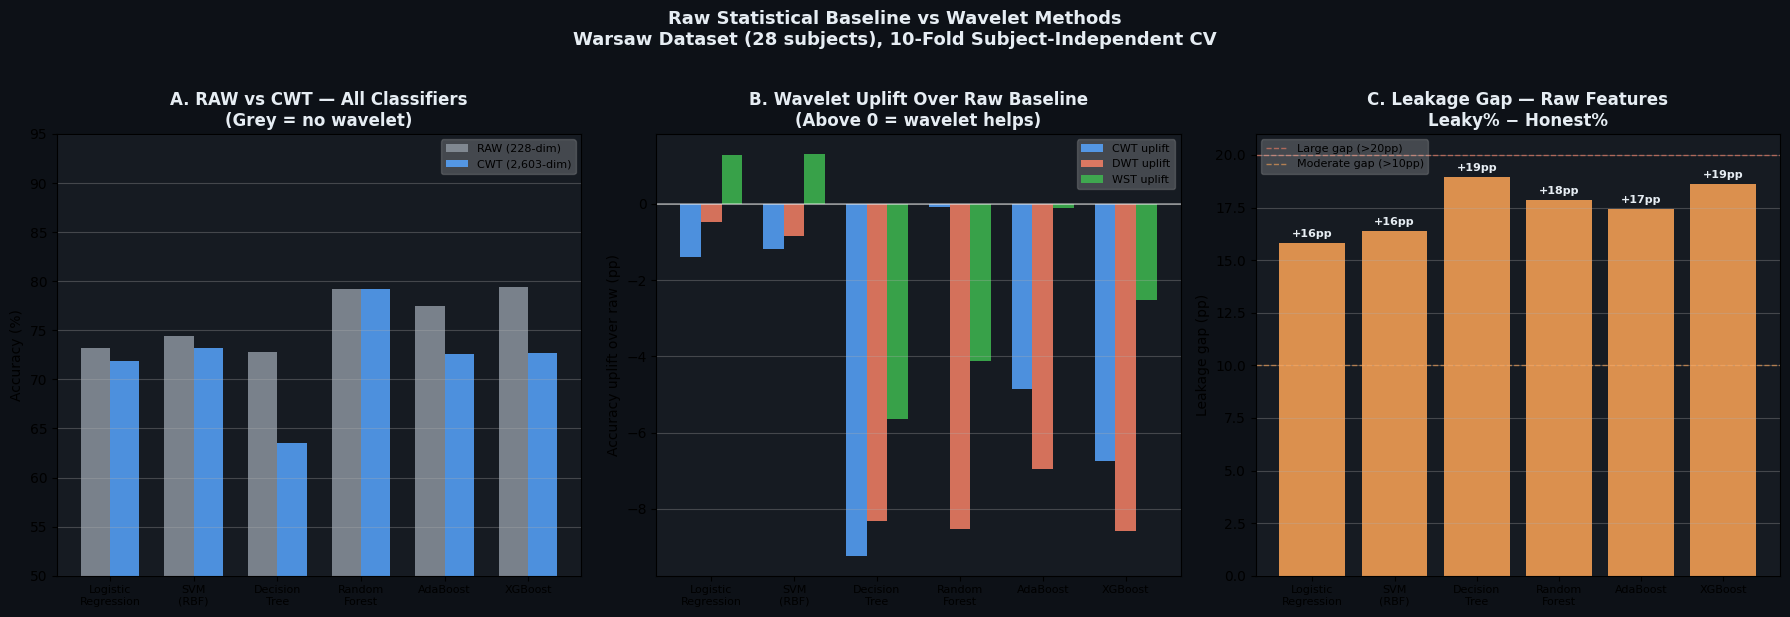

In [19]:
# ── Full results table ─────────────────────────────────
print(f'\n{"="*72}')
print(f'  COMPLETE RESULTS — Raw Baseline + Wavelet Comparison')
print(f'{"="*72}')
print(f'  {"Method":<30} {"Acc%":>8} {"±":>6} '
      f'{"Sens%":>7} {"Spec%":>7} {"κ":>8}')
print(f'  {"─"*70}')

# Raw first
for name in models:
    r   = results_raw[name]
    acc = np.mean(r['acc'])*100
    std = np.std(r['acc'])*100
    sen = np.mean(r['sens'])*100
    spc = np.mean(r['spec'])*100
    kap = np.mean(r['kappa'])
    star = ' ★' if name == best_raw else ''
    print(f'  {"RAW + "+name:<30} {acc:>7.2f}%  '
          f'±{std:>4.1f}%  {sen:>6.1f}%  '
          f'{spc:>6.1f}%  {kap:>7.3f}{star}')

print(f'  {"─"*70}')

# CWT for comparison
for name in models:
    r   = results_cwt[name]
    acc = np.mean(r['acc'])*100
    std = np.std(r['acc'])*100
    sen = np.mean(r['sens'])*100
    spc = np.mean(r['spec'])*100
    kap = np.mean(r['kappa'])
    print(f'  {"CWT + "+name:<30} {acc:>7.2f}%  '
          f'±{std:>4.1f}%  {sen:>6.1f}%  '
          f'{spc:>6.1f}%  {kap:>7.3f}')

print(f'{"="*72}')
print(f'\n  Paper (Gosala 2023, leaky)  : 97.98%')
print(f'  Best honest CWT             : ~{best_cwt_acc:.2f}%')
print(f'  Best honest RAW             : ~{best_acc_raw:.2f}%')
print(f'  Wavelet uplift              : ~{uplift:.1f} pp')

# ── Save ──────────────────────────────────────────────
with open(os.path.join(CACHE_DIR, 'raw_results.pkl'), 'wb') as f:
    pickle.dump({
        'honest': results_raw,
        'leaky' : results_raw_leaky,
    }, f)
print(f'\n✅ Raw baseline results saved')

# ── Visualisation ──────────────────────────────────────
DARK_BG  = '#0D1117'
PANEL_BG = '#161B22'
TEXT_CLR = '#E6EDF3'
MUTED    = '#8B949E'
CLF_COLORS = ['#58A6FF','#3FB950','#F78166',
              '#D2A8FF','#FFA657','#79C0FF']
clf_names = list(models.keys())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(DARK_BG)

# Panel A: RAW vs CWT accuracy per classifier
ax = axes[0]; ax.set_facecolor(PANEL_BG)
x = np.arange(len(clf_names)); w = 0.35
raw_accs = [np.mean(results_raw[n]['acc'])*100 for n in clf_names]
cwt_accs = [np.mean(results_cwt[n]['acc'])*100 for n in clf_names]
ax.bar(x-w/2, raw_accs, w, label='RAW (228-dim)',
       color=MUTED, alpha=0.85)
ax.bar(x+w/2, cwt_accs, w, label='CWT (2,603-dim)',
       color='#58A6FF', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(
    [n.replace(' ','\n') for n in clf_names], fontsize=8)
ax.set_ylabel('Accuracy (%)')
ax.set_title('A. RAW vs CWT — All Classifiers\n'
             '(Grey = no wavelet)',
             color=TEXT_CLR, fontweight='bold')
ax.set_ylim(50, 95); ax.legend(fontsize=8, framealpha=0.2)
ax.grid(True, alpha=0.3, axis='y')

# Panel B: Wavelet uplift over raw
ax = axes[1]; ax.set_facecolor(PANEL_BG)
uplift_cwt = [c - r for c, r in zip(cwt_accs, raw_accs)]
wst_accs   = [np.mean(results_wst[n]['acc'])*100 for n in clf_names]
dwt_accs   = [np.mean(results_dwt[n]['acc'])*100 for n in clf_names]
uplift_wst = [w - r for w, r in zip(wst_accs, raw_accs)]
uplift_dwt = [d - r for d, r in zip(dwt_accs, raw_accs)]
x = np.arange(len(clf_names)); w = 0.25
ax.bar(x-w,   uplift_cwt, w, label='CWT uplift',
       color='#58A6FF', alpha=0.85)
ax.bar(x,     uplift_dwt, w, label='DWT uplift',
       color='#F78166', alpha=0.85)
ax.bar(x+w,   uplift_wst, w, label='WST uplift',
       color='#3FB950', alpha=0.85)
ax.axhline(0, color='white', lw=1.2, alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(
    [n.replace(' ','\n') for n in clf_names], fontsize=8)
ax.set_ylabel('Accuracy uplift over raw (pp)')
ax.set_title('B. Wavelet Uplift Over Raw Baseline\n'
             '(Above 0 = wavelet helps)',
             color=TEXT_CLR, fontweight='bold')
ax.legend(fontsize=8, framealpha=0.2)
ax.grid(True, alpha=0.3, axis='y')

# Panel C: Leaky vs honest gap (raw features)
ax = axes[2]; ax.set_facecolor(PANEL_BG)
leaky_accs_raw  = [np.mean(results_raw_leaky[n]['acc'])*100
                   for n in clf_names]
honest_accs_raw = [np.mean(results_raw[n]['acc'])*100
                   for n in clf_names]
gap_vals = [l-h for l,h in zip(leaky_accs_raw, honest_accs_raw)]
gap_clrs = ['#F78166' if g>20 else '#FFA657' if g>10
            else '#3FB950' for g in gap_vals]
ax.bar(range(len(clf_names)), gap_vals,
       color=gap_clrs, alpha=0.85)
for i, val in enumerate(gap_vals):
    ax.text(i, val+0.3, f'+{val:.0f}pp',
            ha='center', fontsize=8,
            color=TEXT_CLR, fontweight='bold')
ax.axhline(20, color='#F78166', ls='--', lw=1,
           alpha=0.6, label='Large gap (>20pp)')
ax.axhline(10, color='#FFA657', ls='--', lw=1,
           alpha=0.6, label='Moderate gap (>10pp)')
ax.set_xticks(range(len(clf_names)))
ax.set_xticklabels(
    [n.replace(' ','\n') for n in clf_names], fontsize=8)
ax.set_ylabel('Leakage gap (pp)')
ax.set_title('C. Leakage Gap — Raw Features\n'
             'Leaky% − Honest%',
             color=TEXT_CLR, fontweight='bold')
ax.legend(fontsize=8, framealpha=0.2)
ax.grid(True, alpha=0.3, axis='y')

fig.suptitle(
    'Raw Statistical Baseline vs Wavelet Methods\n'
    'Warsaw Dataset (28 subjects), '
    '10-Fold Subject-Independent CV',
    fontsize=13, color=TEXT_CLR,
    y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig(
    os.path.join(CACHE_DIR, 'figures/raw_baseline.png'),
    dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()